In [37]:
import sys
# Save original path
original_sys_path = sys.path.copy()
# Remove custom entries not in original sys.path (like PYTHONPATH entries) to avoid numpy conflict
sys.path = [p for p in sys.path if "amber" not in p]
for i, path in enumerate(sys.path):
    print(f"{i}: {path}")

0: 
1: /localhome/shuchen/software/plumed-2.8.2/python
2: /localhome/shuchen/projects/ALG8/gitlab/analysis
3: /usr/share/pdb2pqr
4: /localhome/shuchen/.conda/envs/shu_pytraj/lib/python36.zip
5: /localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6
6: /localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/lib-dynload
7: /localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages
8: /localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/IPython/extensions
9: /home/shuchen/.ipython


In [38]:
from ALG8_class import *
import os
import seaborn as sns
# %load_ext autoreload
# %autoreload 2

# Load object

In [39]:
# Analyze the data if you don't have the pkl results yet
# adjust do your own path
from ALG8_class import *
object_path = "./objects/"
figdir = './Figures/ALG8_posttransfer/'
N_run = 5
# wt with Glc
prefixes = ['ALG8_D36_post_transfer', 'ALG8_D36_H40d_post_transfer', 'ALG8_D36_H40db_post_transfer',
            'ALG8_N36_post_transfer', 'ALG8_N36_H40d_post_transfer', 'ALG8_N36_H40db_post_transfer',
            ]
objs_out = [[object_path+f'{prefix}_run{run}_analysis_obj.pkl' for run in range(1,N_run+1)] for prefix in prefixes]

object_names = [r'$Hs$ALG8 D36 (H40$_{\epsilon}$)', r'$Hs$ALG8 D36 (H40$_{\delta}$)', r'$Hs$ALG8 D36 (H40$_{double}$)',
                r'$Hs$ALG8 N36 (H40$_{\epsilon}$)', r'$Hs$ALG8 N36 (H40$_{\delta}$)', r'$Hs$ALG8 N36 (H40$_{double}$)',
                ]

object_lists = [[] for i in range(len(object_names))]
for i_list, object_list in enumerate(object_lists):
    # load
    for i_obj in range(N_run):
        obj_file = objs_out[i_list][i_obj]
        if os.path.exists(obj_file):
            obj = pickle.load(open(obj_file, 'rb'))
            object_list.append(obj)
        else:
            print(f"File {obj_file} not found. Please run the analysis to generate it.")


# lid helix hbond analysis
fig = plt.figure(figsize=(10,6),dpi=100)
discard = 500 # 4000 frames for 800ns -> 500 frames for 100ns
density_range = (0, 1)
for i, object_list in enumerate(object_lists): 
    print(f"Processing {object_names[i]}")
    lid_helix_hbonds = np.concatenate([obj.lid_helix_hbonds[discard:] for obj in object_list])
    lid_rmsd         = np.concatenate([obj.lid_helix_rmsd[discard:] for obj in object_list])
    print(f" object: {object_names[i]}, length: {len(lid_helix_hbonds)}")
    ax = fig.add_subplot(2,3,i+1)
    hbond_bins = np.arange(-0.5, 5.5, 1)
    rmsd_bins  = np.arange(0, 5.0, 0.2)
    hbond_centers = 0.5 * (hbond_bins[:-1] + hbond_bins[1:])
    rmsd_centers  = 0.5 * (rmsd_bins[:-1] + rmsd_bins[1:])
    H, xedges, yedges = np.histogram2d(lid_helix_hbonds, lid_rmsd, bins=[hbond_bins, rmsd_bins], density=True)   
    H = H.T
    X, Y = np.meshgrid(hbond_centers, rmsd_centers)
    pcm = ax.pcolormesh(X, Y, H, cmap='Blues', shading='auto')
    pcm.set_clim(density_range)
    fig.colorbar(pcm, ax=ax, label='Density')
    ax.set_xlabel('Number of Lid-Helix H-bonds')
    ax.set_ylabel('Lid Helix RMSD (Å)')
    ax.set_title(object_names[i])
plt.tight_layout()

Processing $Hs$ALG8 D36 (H40$_{\epsilon}$)
Processing $Hs$ALG8 D36 (H40$_{\delta}$)
Processing $Hs$ALG8 D36 (H40$_{double}$)
Processing $Hs$ALG8 N36 (H40$_{\epsilon}$)
Processing $Hs$ALG8 N36 (H40$_{\delta}$)
Processing $Hs$ALG8 N36 (H40$_{double}$)


Text(0.5, 0, 'Lid Helix RMSD (Å)')

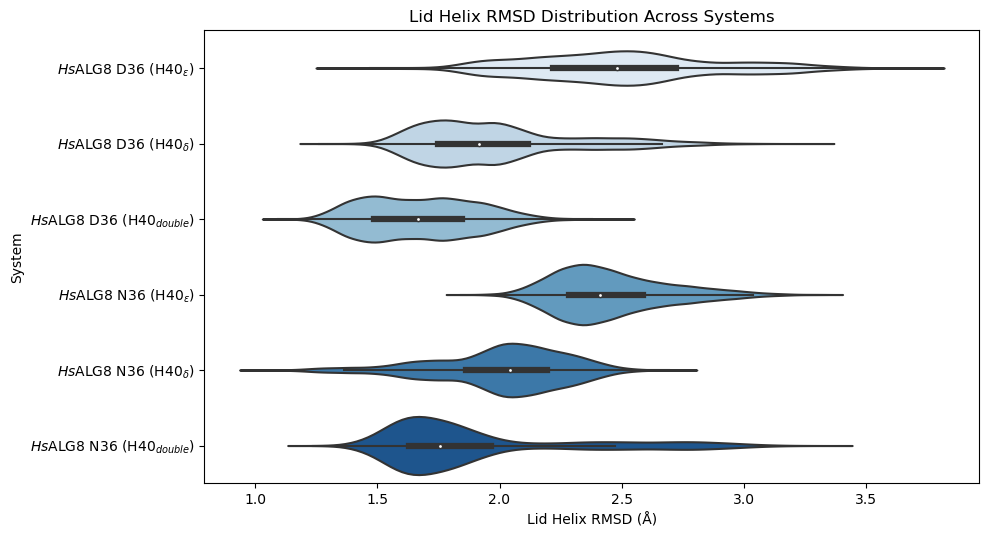

In [40]:
# lid helix hbond analysis
fig = plt.figure(figsize=(10,6),dpi=100)
discard = 500 # 4000 frames for 800ns -> 500 frames for 100ns
df = pd.DataFrame([], columns=['Lid Helix RMSD', 'Counts', 'System'])
for i, object_list in enumerate(object_lists): 
    print(f"Processing {object_names[i]}")
    lid_rmsd         = np.concatenate([obj.lid_helix_rmsd[discard:] for obj in object_list])
    df_temp = pd.DataFrame(columns=['Lid Helix RMSD', 'Counts', 'System'], data={
        'Lid Helix RMSD': lid_rmsd,
        'Counts': np.ones_like(lid_rmsd),
        'System': [object_names[i]] * len(lid_rmsd)
    })
    df = pd.concat([df, df_temp], ignore_index=True)    
sns.violinplot(data=df, x='Lid Helix RMSD', y='System', palette='Blues')
plt.title('Lid Helix RMSD Distribution Across Systems')
plt.xlabel('Lid Helix RMSD (Å)')

No handles with labels found to put in legend.


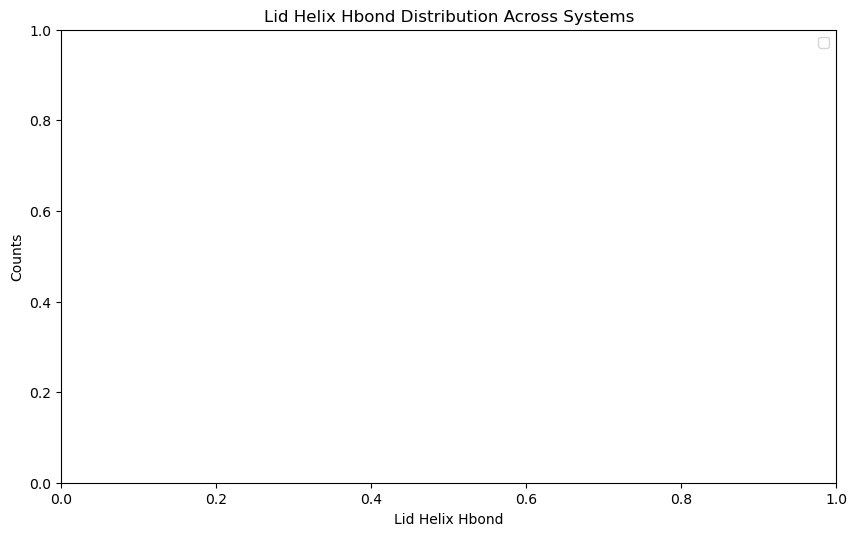

In [41]:
# lid helix hbond analysis
fig = plt.figure(figsize=(10,6),dpi=100)
discard = 500 # 4000 frames for 800ns -> 500 frames for 100ns
df = pd.DataFrame([], columns=['Lid Helix RMSD', 'Counts', 'System'])
for i, object_list in enumerate(object_lists): 
    continue
    lid_helix_hbonds = np.concatenate([obj.lid_helix_hbonds[discard:] for obj in object_list])
    lid_helix_hbonds = sliding_average(lid_helix_hbonds, window_size=10)
    df_temp = pd.DataFrame(columns=['Lid Helix Hbond', 'Counts', 'System'], data={
        'Lid Helix Hbond': lid_helix_hbonds,
        'Counts': np.ones_like(lid_helix_hbonds),
        'System': [object_names[i]] * len(lid_helix_hbonds)
    })
    df = pd.concat([df, df_temp], ignore_index=True)    
# sns.violinplot(data=df, x='Lid Helix Hbond', y='System', palette='Blues')
plt.title('Lid Helix Hbond Distribution Across Systems')
plt.xlabel('Lid Helix Hbond')
plt.ylabel('Counts')
plt.legend()

## RMSD

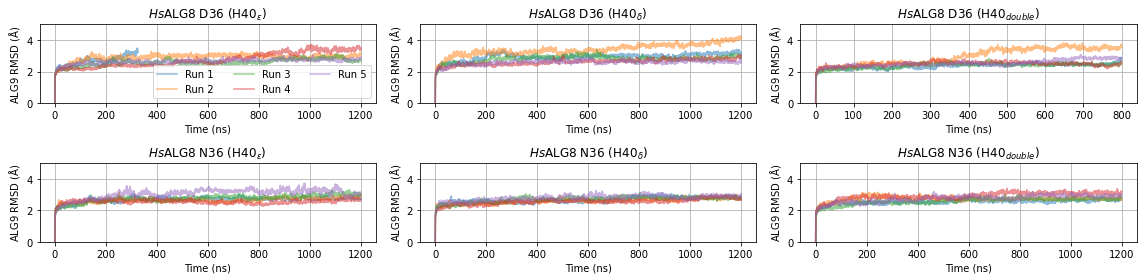

In [42]:
fig, axs = plt.subplots(2,3,figsize=(16,4))
ylim = [0,5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.pro_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.pro_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_xlabel('Time (ns)')
    ax.set_title(object_names[i_object_list])
    ax.set_ylabel(r'ALG9 RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_ALG8.svg'
plt.savefig(filename)

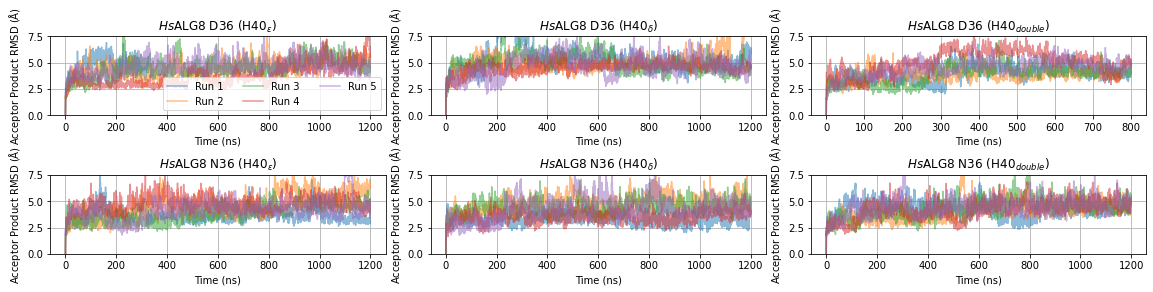

In [43]:
fig, axs = plt.subplots(2,3,figsize=(16,4))
ylim = [0,7.5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.AS_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.AS_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'Acceptor Product RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_AS.svg'
plt.savefig(filename)

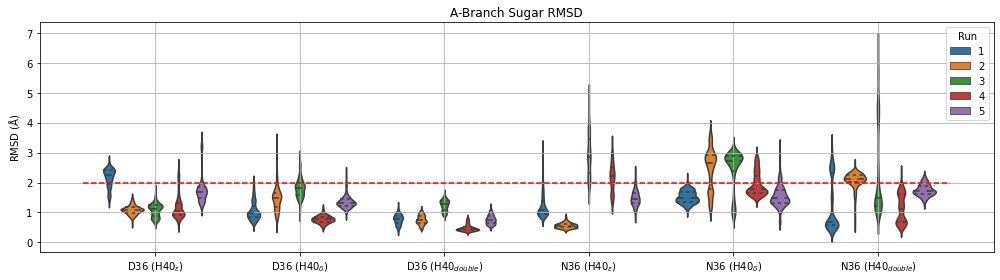

In [44]:
fig, axs = plt.subplots(1,1,figsize=(14,4))
rmsd_cutoff = 2.0
df = pd.DataFrame()
sliding_window = 10
discard_ratio = 0.1
for i_object_list, object_list in enumerate(object_lists):
    # violin plot for DP RMSD
    for i_obj, obj in enumerate(object_list):
        df_ = pd.DataFrame()
        df_['AS RMSD'] = sliding_average(obj.A_sugar_rmsd[int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['Object'] = ' '.join(object_names[i_object_list].split(' ')[1:])
        df_['Run'] = i_obj + 1
        df = pd.concat([df, df_], ignore_index=True)
sns.violinplot(x='Object', y='AS RMSD', hue='Run', data=df,  inner='quartile')
plt.hlines(rmsd_cutoff, -0.5, len(object_lists)-0.5, colors='r', linestyles='dashed', label='RMSD Cutoff')
# plt.text(len(object_lists)-0.5, rmsd_cutoff+0.1, 'RMSD Cutoff', color='r', va='bottom', ha='right')
plt.title('A-Branch Sugar RMSD')
plt.ylabel(r'RMSD ($\rm \AA$)')
plt.xlabel('')
plt.grid()
plt.tight_layout()
filename = figdir+'Violin_Asugar_RMSD.svg'
plt.savefig(filename)

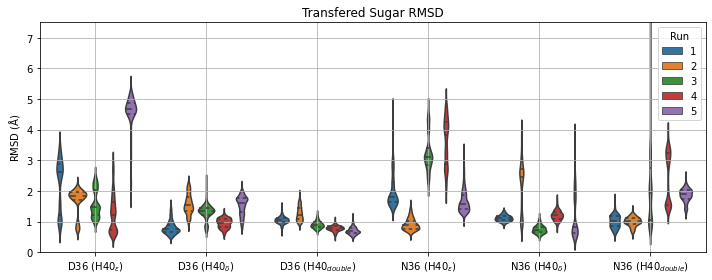

In [45]:
fig, axs = plt.subplots(1,1,figsize=(10,4))
rmsd_cutoff = 2.0
df = pd.DataFrame()
sliding_window = 10
discard_ratio = 0.1
for i_object_list, object_list in enumerate(object_lists):
    # violin plot for DP RMSD
    for i_obj, obj in enumerate(object_list):
        df_ = pd.DataFrame()
        df_['AS RMSD'] = sliding_average(obj.D_sugar_rmsd[int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['Object'] = ' '.join(object_names[i_object_list].split(' ')[1:])
        df_['Run'] = i_obj + 1
        df = pd.concat([df, df_], ignore_index=True)
sns.violinplot(x='Object', y='AS RMSD', hue='Run', data=df,  inner='quartile')
# plt.hlines(rmsd_cutoff, -0.5, len(object_lists)-0.5, colors='r', linestyles='dashed', label='RMSD Cutoff')
# plt.text(len(object_lists)-0.5, rmsd_cutoff+0.1, 'RMSD Cutoff', color='r', va='bottom', ha='right')
plt.title('Transfered Sugar RMSD')
plt.ylabel(r'RMSD ($\rm \AA$)')
plt.ylim(0,7.5)
plt.xlabel('')
plt.grid()
plt.tight_layout()
filename = figdir+'Violin_Dsugar_RMSD.png'
plt.savefig(filename, dpi=300)

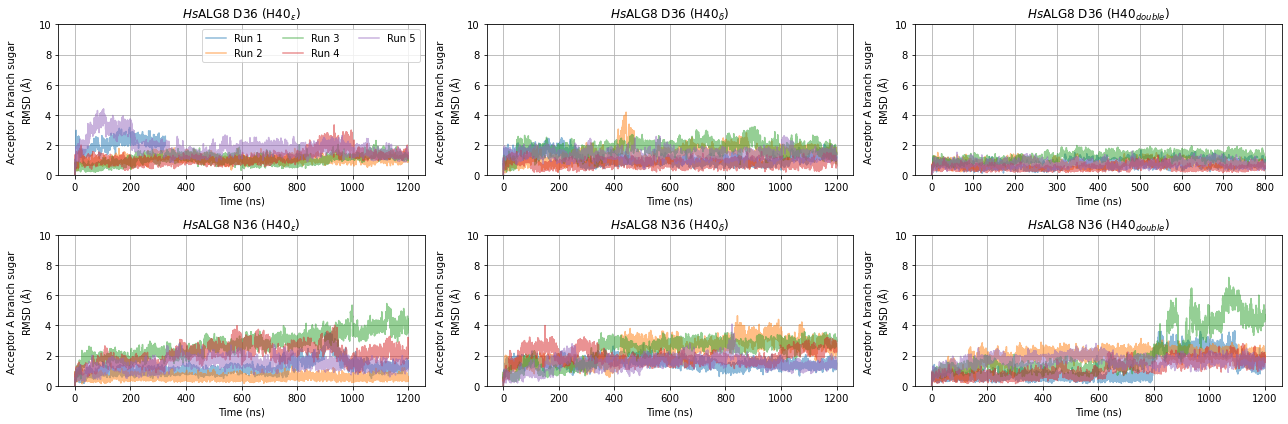

In [46]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,10]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.A_sugar_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.A_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Acceptor A branch sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Asugar.png'
plt.savefig(filename)

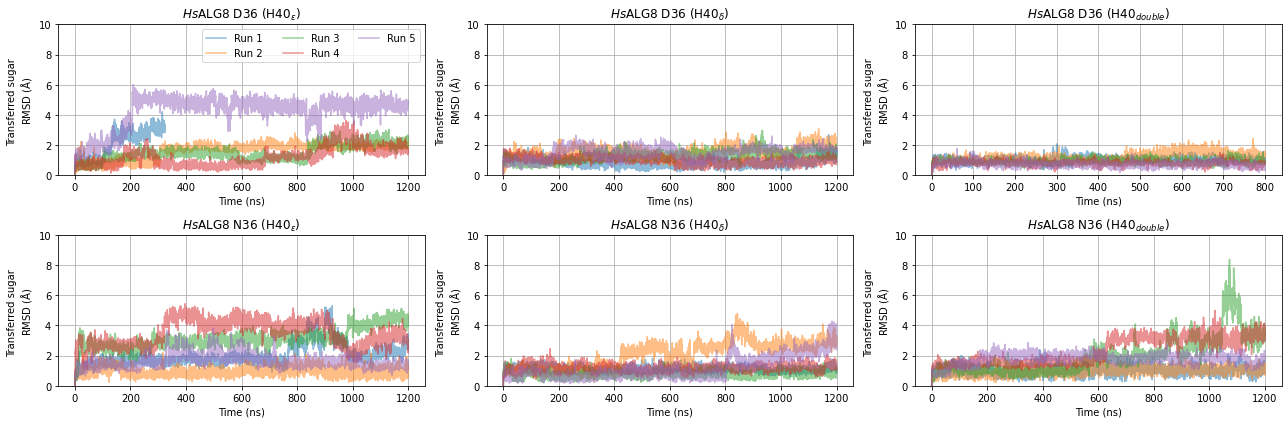

In [47]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,10]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.D_sugar_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.D_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Transferred sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Dsugar.png'
plt.savefig(filename)

# RMSF plots

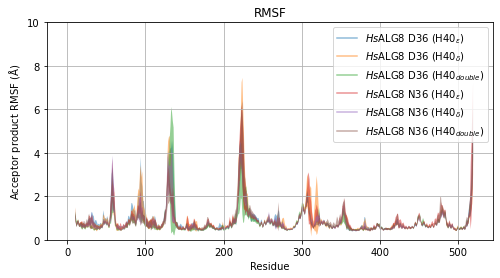

In [48]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
resid_offset = 10
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.pro_rmsf[:,1]
    rmsf = np.array(rmsf)
    axs.plot(rmsf.mean(axis=0)+resid_offset, label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.legend()
# axs.set_xlim([resid_offset, len(obj.DS_rmsf[:,0])+resid_offset])
axs.set_ylim(ylim)
axs.grid()
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'Acceptor product RMSF ($\rm \AA$)')
filename = figdir+'RMSF_ALG8.svg'
plt.savefig(filename)

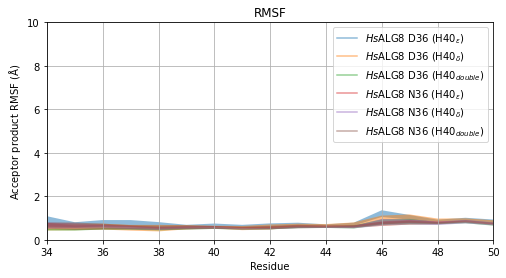

In [49]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
xlim  =[24,40]
resid_offset = 10
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.pro_rmsf[:,1]
    rmsf = np.array(rmsf)
    axs.plot(rmsf.mean(axis=0)+resid_offset, label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.legend()
axs.set_xlim([xlim[0]+resid_offset, xlim[1]+resid_offset])
axs.set_ylim(ylim)
axs.grid()
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'Acceptor product RMSF ($\rm \AA$)')
filename = figdir+'RMSF_ALG8_S34-L50.svg'
plt.savefig(filename)

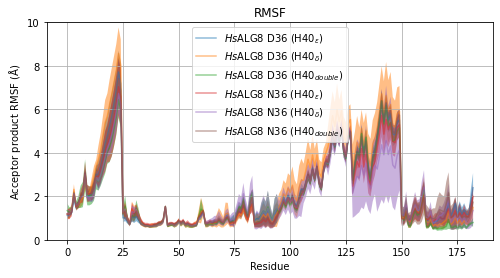

In [50]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
resid_offset = 0
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.AS_rmsf[:,1]
    rmsf = np.array(rmsf)
    axs.plot(rmsf.mean(axis=0)+resid_offset, label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.AS_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.legend()
# axs.set_xlim([resid_offset, len(obj.DS_rmsf[:,0])+resid_offset])
axs.set_ylim(ylim)
axs.grid()
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'Acceptor product RMSF ($\rm \AA$)')
filename = figdir+'RMSF_AP.svg'
plt.savefig(filename)

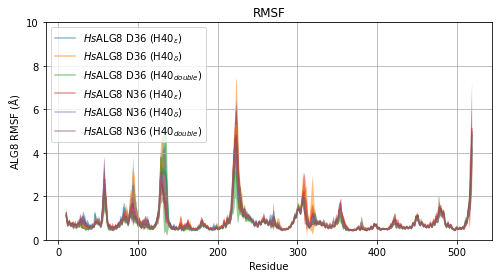

In [51]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
resid_offset = 10
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.pro_rmsf[:,1]
    rmsf = np.array(rmsf)
    
    axs.plot(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset, rmsf.mean(axis=0), label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.grid()
axs.legend()
# axs.set_xlim([resid_offset, len(obj.protein_rmsf[:,0])+resid_offset])
axs.set_ylim(ylim)
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'ALG8 RMSF ($\rm \AA$)')
filename = figdir+'RMSF_ALG8.svg'
plt.savefig(filename)

Text(0, 0.5, 'ALG8 RMSF ($\\rm \\AA$)')

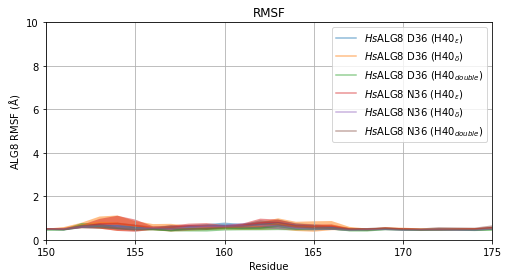

In [52]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
xlim = [150,175]
resid_offset = 10
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.pro_rmsf[:,1]
    rmsf = np.array(rmsf)
    
    axs.plot(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset, rmsf.mean(axis=0), label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.grid()
axs.legend()
# axs.set_xlim([resid_offset, len(obj.protein_rmsf[:,0])+resid_offset])
axs.set_ylim(ylim)
axs.set_xlim(xlim)
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'ALG8 RMSF ($\rm \AA$)')


# Hbond

In [53]:
obj.intra_hydrogen_bonds.shape

(2, 2, 6000)

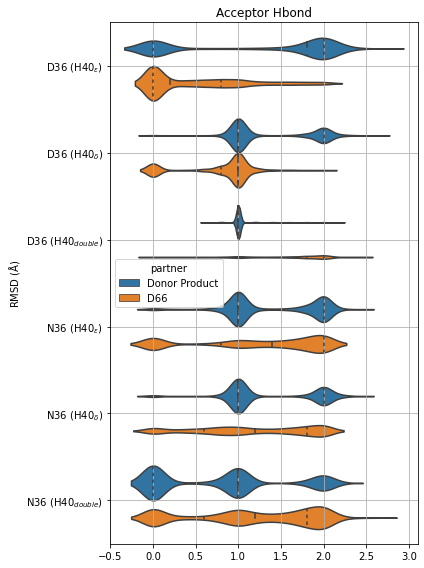

In [54]:
# Product Hbond (acceptor product and donor product)
fig, axs = plt.subplots(1,1,figsize=(6,8))
rmsd_cutoff = 2.0

sliding_window = 5
discard_ratio = 0.8
df = pd.DataFrame()
for i_object_list, object_list in enumerate(object_lists):
    # violin plot for DP RMSD
    for i_obj, obj in enumerate(object_list):
        # AP and DP Hbond
        df_ = pd.DataFrame()
        df_['Hbond']  = sliding_average(obj.intra_hydrogen_bonds[0,1,int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['partner'] = 'Donor Product'
        df_['Object'] = ' '.join(object_names[i_object_list].split(' ')[1:])
        df_['Run'] = i_obj + 1
        df = pd.concat([df, df_], ignore_index=True)
        # D66 Hbond
        df_['Hbond']   = sliding_average(obj.protein_substrates_bonds[0,6][int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['partner'] = 'D66'
        df = pd.concat([df, df_], ignore_index=True)
sns.violinplot(y='Object', x='Hbond', hue='partner', data=df, orient='h', inner='quartile')

# plt.hlines(rmsd_cutoff, -0.5, len(object_lists)-0.5, colors='r', linestyles='dashed', label='RMSD Cutoff')
# plt.text(len(object_lists)-0.5, rmsd_cutoff+0.1, 'RMSD Cutoff', color='r', va='bottom', ha='right')
plt.title('Acceptor Hbond')
plt.ylabel(r'RMSD ($\rm \AA$)')
plt.xlabel('')
plt.grid()
plt.tight_layout()
filename = figdir+'Violin_Acceptor_Hbond.png'
plt.savefig(filename)

In [55]:
discard_ratio

0.8

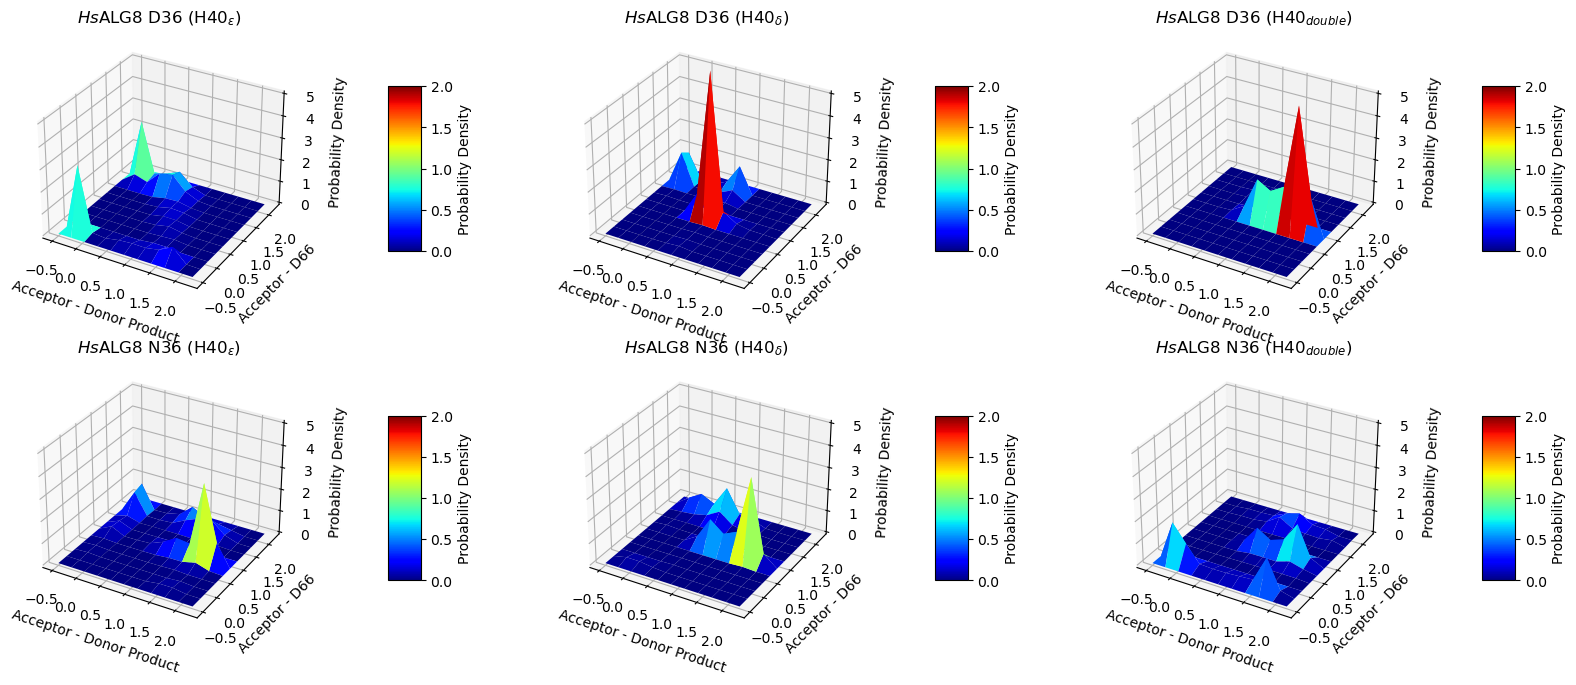

In [72]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(20,8),dpi=100)
discard_ratio = 0.8
log = False
cmap = 'Blues'
sliding_window = 20
for i, object_list in enumerate(object_lists):
    acceptor_donor_hbond = np.concatenate([sliding_average(obj.intra_hydrogen_bonds[0,1,int(len(obj.pro_rmsd)*discard_ratio):], 
                                                          window_size=sliding_window) for obj in object_list])
    acceptor_D66_hbond = np.concatenate([sliding_average(obj.protein_substrates_bonds[0,6][int(len(obj.pro_rmsd)*discard_ratio):], 
                                                          window_size=sliding_window) for obj in object_list])
    ax = fig.add_subplot(2,3,i+1 , projection='3d')
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_hbond = 0.2
    Hbond_edges     = np.linspace(-0.5,2.5, 12)

    H, _, _ = np.histogram2d(
        acceptor_donor_hbond,acceptor_D66_hbond ,bins=(Hbond_edges, Hbond_edges),density=True)
    # H[H==0] = np.nan
    x,y  = np.meshgrid(Hbond_edges, Hbond_edges)
    x = 0.5 * (x[:-1,:-1] + x[1:,:-1])
    y = 0.5 * (y[:-1,:-1] + y[:-1,1:])
    im = ax.plot_surface(x,y, H, cmap=plt.cm.jet)
    im.set_clim(0,2)

    ax.set_title(object_names[i])
    ax.set_zlim(0,5)
    ax.set_xlabel("Acceptor - Donor Product")
    ax.set_ylabel("Acceptor - D66")
    ax.set_zlabel('Probability Density')

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.6, aspect=5, pad=0.2)

# plt.tight_layout()
filename = figdir+'Hbond_Acceptor_3D.png'
plt.savefig(filename)



In [57]:
np.linspace(-0.25,2.75, 7)

array([-0.25,  0.25,  0.75,  1.25,  1.75,  2.25,  2.75])

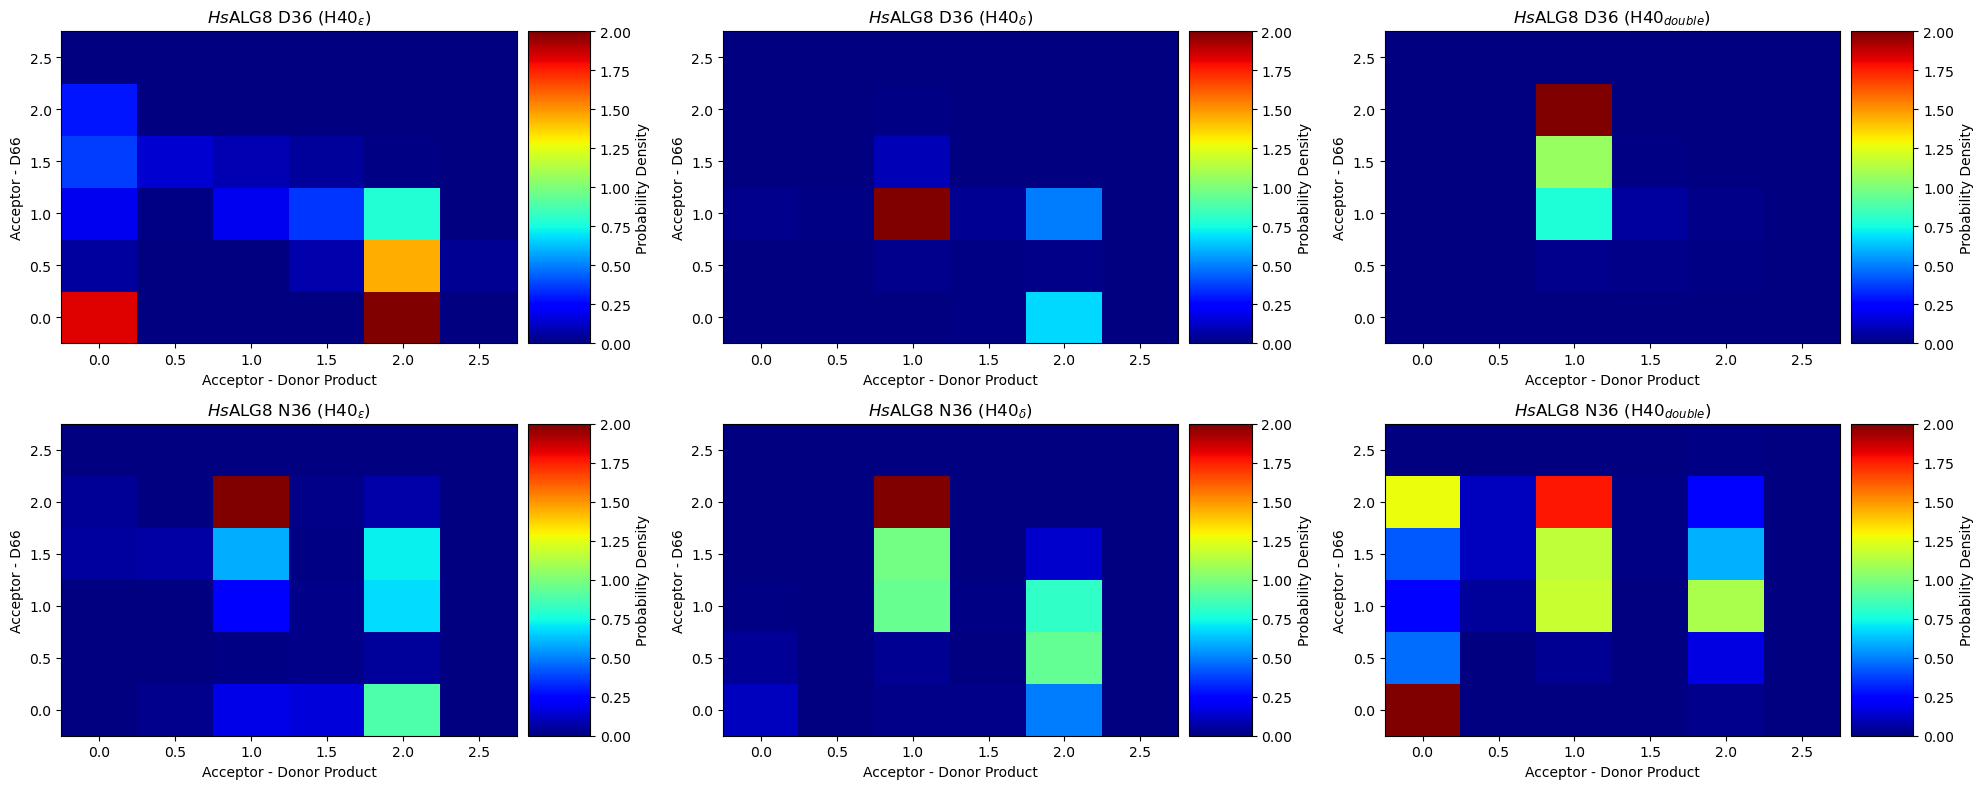

In [58]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(20,8),dpi=100)

log = False
cmap = 'Blues'
sliding_window = 20
for i, object_list in enumerate(object_lists):
    acceptor_donor_hbond = np.concatenate([sliding_average(obj.intra_hydrogen_bonds[0,1,int(len(obj.pro_rmsd)*discard_ratio):], 
                                                          window_size=sliding_window) for obj in object_list])
    acceptor_D66_hbond = np.concatenate([sliding_average(obj.protein_substrates_bonds[0,6][int(len(obj.pro_rmsd)*discard_ratio):], 
                                                          window_size=sliding_window) for obj in object_list])
    ax = fig.add_subplot(2,3,i+1)
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_r = 0.3
    binsize_theta = 180/50
    Hbond_edges     = np.linspace(-0.25,2.75, 7)
    ax.hist2d(acceptor_donor_hbond, acceptor_D66_hbond ,bins=(Hbond_edges, Hbond_edges),density=True,cmap=plt.cm.jet)
    ax.set_title(object_names[i])
    ax.set_xlabel("Acceptor - Donor Product")
    ax.set_ylabel("Acceptor - D66")
    # ax.set_xticks(np.arange(3,16,2))

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5, pad=0.02)
plt.tight_layout()
# plt.tight_layout()
filename = figdir+'Hbond_Acceptor_2D.png'
plt.savefig(filename)



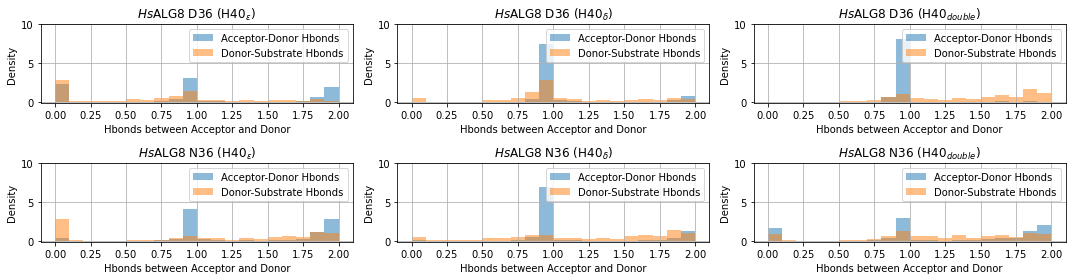

In [59]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
sliding_window = 10
ylim = [-0.1,10]
bins = np.linspace(0,2,21)
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    y1_all = []
    y2_all = []
    for i_obj, obj in enumerate(object_list):
        # x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        y1 = sliding_average(obj.intra_hydrogen_bonds[0,1], window_size=sliding_window)
        y1_all.append(y1) 
        y2 = sliding_average(obj.protein_substrates_bonds[0,6], window_size=sliding_window)
        y2_all.append(y2)

    ax.hist(np.concatenate(y1_all), bins=bins, density=True, alpha=0.5, label='Acceptor-Donor Hbonds')
    ax.hist(np.concatenate(y2_all), bins=bins, density=True, alpha=0.5, label='Donor-Substrate Hbonds')
    ax.legend()
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Hbonds between Acceptor and Donor')
    ax.set_ylabel('Density')
    ax.grid()
plt.tight_layout()
filename = figdir+'AP-DP_hbonds_1Dhist.png'
plt.savefig(filename)

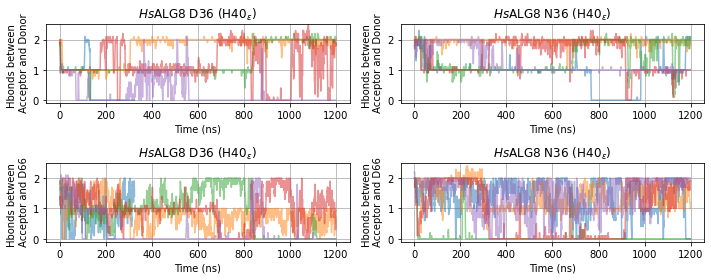

In [76]:
fig, axs = plt.subplots(2,2,figsize=(5*2,4))
sliding_window = 10
ylim = [-0.1,2.5]
show_idnex = [0,3]
for i_object_list, object_list in enumerate([object_lists[i] for i in show_idnex]):
    ax1 = axs[0][i_object_list]
    ax2 = axs[1][i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        # x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        y = sliding_average(obj.intra_hydrogen_bonds[0,1], window_size=sliding_window)
        x = sliding_average(np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)], window_size=sliding_window)
        ax1.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        y = sliding_average(obj.protein_substrates_bonds[0,6], window_size=sliding_window) # D66 hbond
        ax2.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
    # if i_object_list == 0:
    #    ax.legend(ncol=3)
    ax1.set_ylim(ylim)
    ax1.set_title(object_names[show_idnex[i_object_list]])
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Hbonds between \n Acceptor and Donor')
    ax1.grid()
    ax2.set_ylim(ylim)
    ax2.set_title(object_names[show_idnex[i_object_list]])
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Hbonds between \n Acceptor and D66')
    ax2.grid()
plt.tight_layout()
filename = figdir+'AP-hbonds_epsilon.png'
plt.savefig(filename, dpi=300)

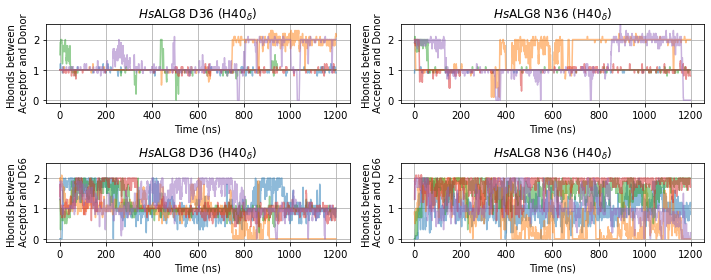

In [77]:
fig, axs = plt.subplots(2,2,figsize=(5*2,4))
sliding_window = 10
ylim = [-0.1,2.5]
show_idnex = [1,4]
for i_object_list, object_list in enumerate([object_lists[i] for i in show_idnex]):
    ax1 = axs[0][i_object_list]
    ax2 = axs[1][i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        # x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        y = sliding_average(obj.intra_hydrogen_bonds[0,1], window_size=sliding_window)
        x = sliding_average(np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)], window_size=sliding_window)
        ax1.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        y = sliding_average(obj.protein_substrates_bonds[0,6], window_size=sliding_window) # D66 hbond
        ax2.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
    # if i_object_list == 0:
    #    ax.legend(ncol=3)
    ax1.set_ylim(ylim)
    ax1.set_title(object_names[show_idnex[i_object_list]])
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Hbonds between \n Acceptor and Donor')
    ax1.grid()
    ax2.set_ylim(ylim)
    ax2.set_title(object_names[show_idnex[i_object_list]])
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Hbonds between \n Acceptor and D66')
    ax2.grid()
plt.tight_layout()
filename = figdir+'AP-hbonds_delta.png'
plt.savefig(filename, dpi=300)

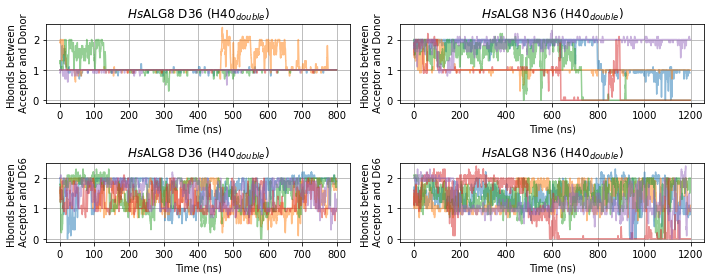

In [78]:
fig, axs = plt.subplots(2,2,figsize=(5*2,4))
sliding_window = 10
ylim = [-0.1,2.5]
show_idnex = [2,5]
for i_object_list, object_list in enumerate([object_lists[i] for i in show_idnex]):
    ax1 = axs[0][i_object_list]
    ax2 = axs[1][i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        # x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        y = sliding_average(obj.intra_hydrogen_bonds[0,1], window_size=sliding_window)
        x = sliding_average(np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)], window_size=sliding_window)
        ax1.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        y = sliding_average(obj.protein_substrates_bonds[0,6], window_size=sliding_window) # D66 hbond
        ax2.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
    # if i_object_list == 0:
    #    ax.legend(ncol=3)
    ax1.set_ylim(ylim)
    ax1.set_title(object_names[show_idnex[i_object_list]])
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Hbonds between \n Acceptor and Donor')
    ax1.grid()
    ax2.set_ylim(ylim)
    ax2.set_title(object_names[show_idnex[i_object_list]])
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Hbonds between \n Acceptor and D66')
    ax2.grid()
plt.tight_layout()
filename = figdir+'AP-hbonds_double.png'
plt.savefig(filename, dpi=300)

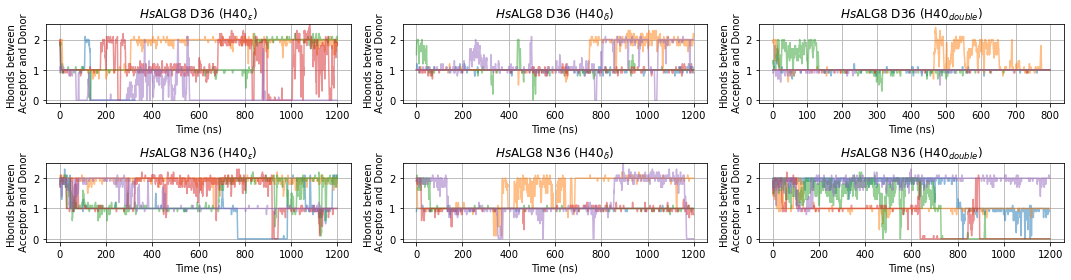

In [60]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
sliding_window = 10
ylim = [-0.1,2.5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        # x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        y = sliding_average(obj.intra_hydrogen_bonds[0,1], window_size=sliding_window)
        x = sliding_average(np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)], window_size=sliding_window)
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
    # if i_object_list == 0:
    #    ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Hbonds between \n Acceptor and Donor')
    ax.grid()
plt.tight_layout()
filename = figdir+'AP-DP_hbonds.png'
plt.savefig(filename)

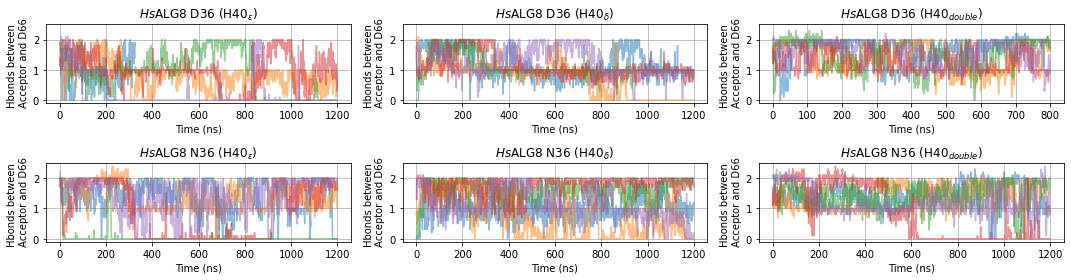

In [61]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
sliding_window = 10
ylim = [-0.1,2.5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        # x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        y = sliding_average(obj.protein_substrates_bonds[0,6], window_size=sliding_window)
        x = sliding_average(np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)], window_size=sliding_window)
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
    # if i_object_list == 0:
    #    ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Hbonds between \n Acceptor and D66')
    ax.grid()
plt.tight_layout()
filename = figdir+'Acceptor_D66_hbonds.png'
plt.savefig(filename)

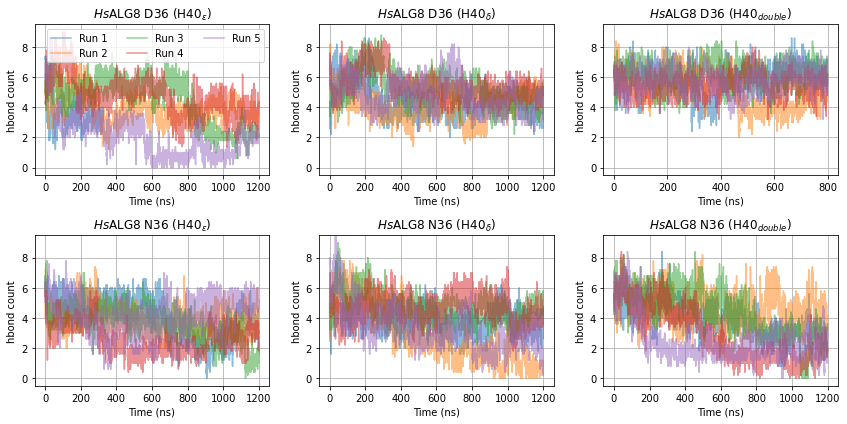

In [62]:
# AS-D82 distance
fig, axs = plt.subplots(2,3,figsize=(2*len(object_lists),6))
axs = axs.flatten()
ylim = [-0.5,9.5]
sliding_window = 5
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    for i_obj, obj in enumerate(object_list):
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(np.sum(obj.protein_substrates_bonds[0],axis=(0)),window_size=sliding_window) 
        ax.plot(x,y , label = f'Run {i_obj+1}',alpha=0.5)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'hbond count')
    ax.grid()
    ax.set_ylim(ylim)
axs[0].legend(ncol=3)
plt.tight_layout()
filename = figdir+'/hbond.png'
plt.savefig(filename, dpi=300)    

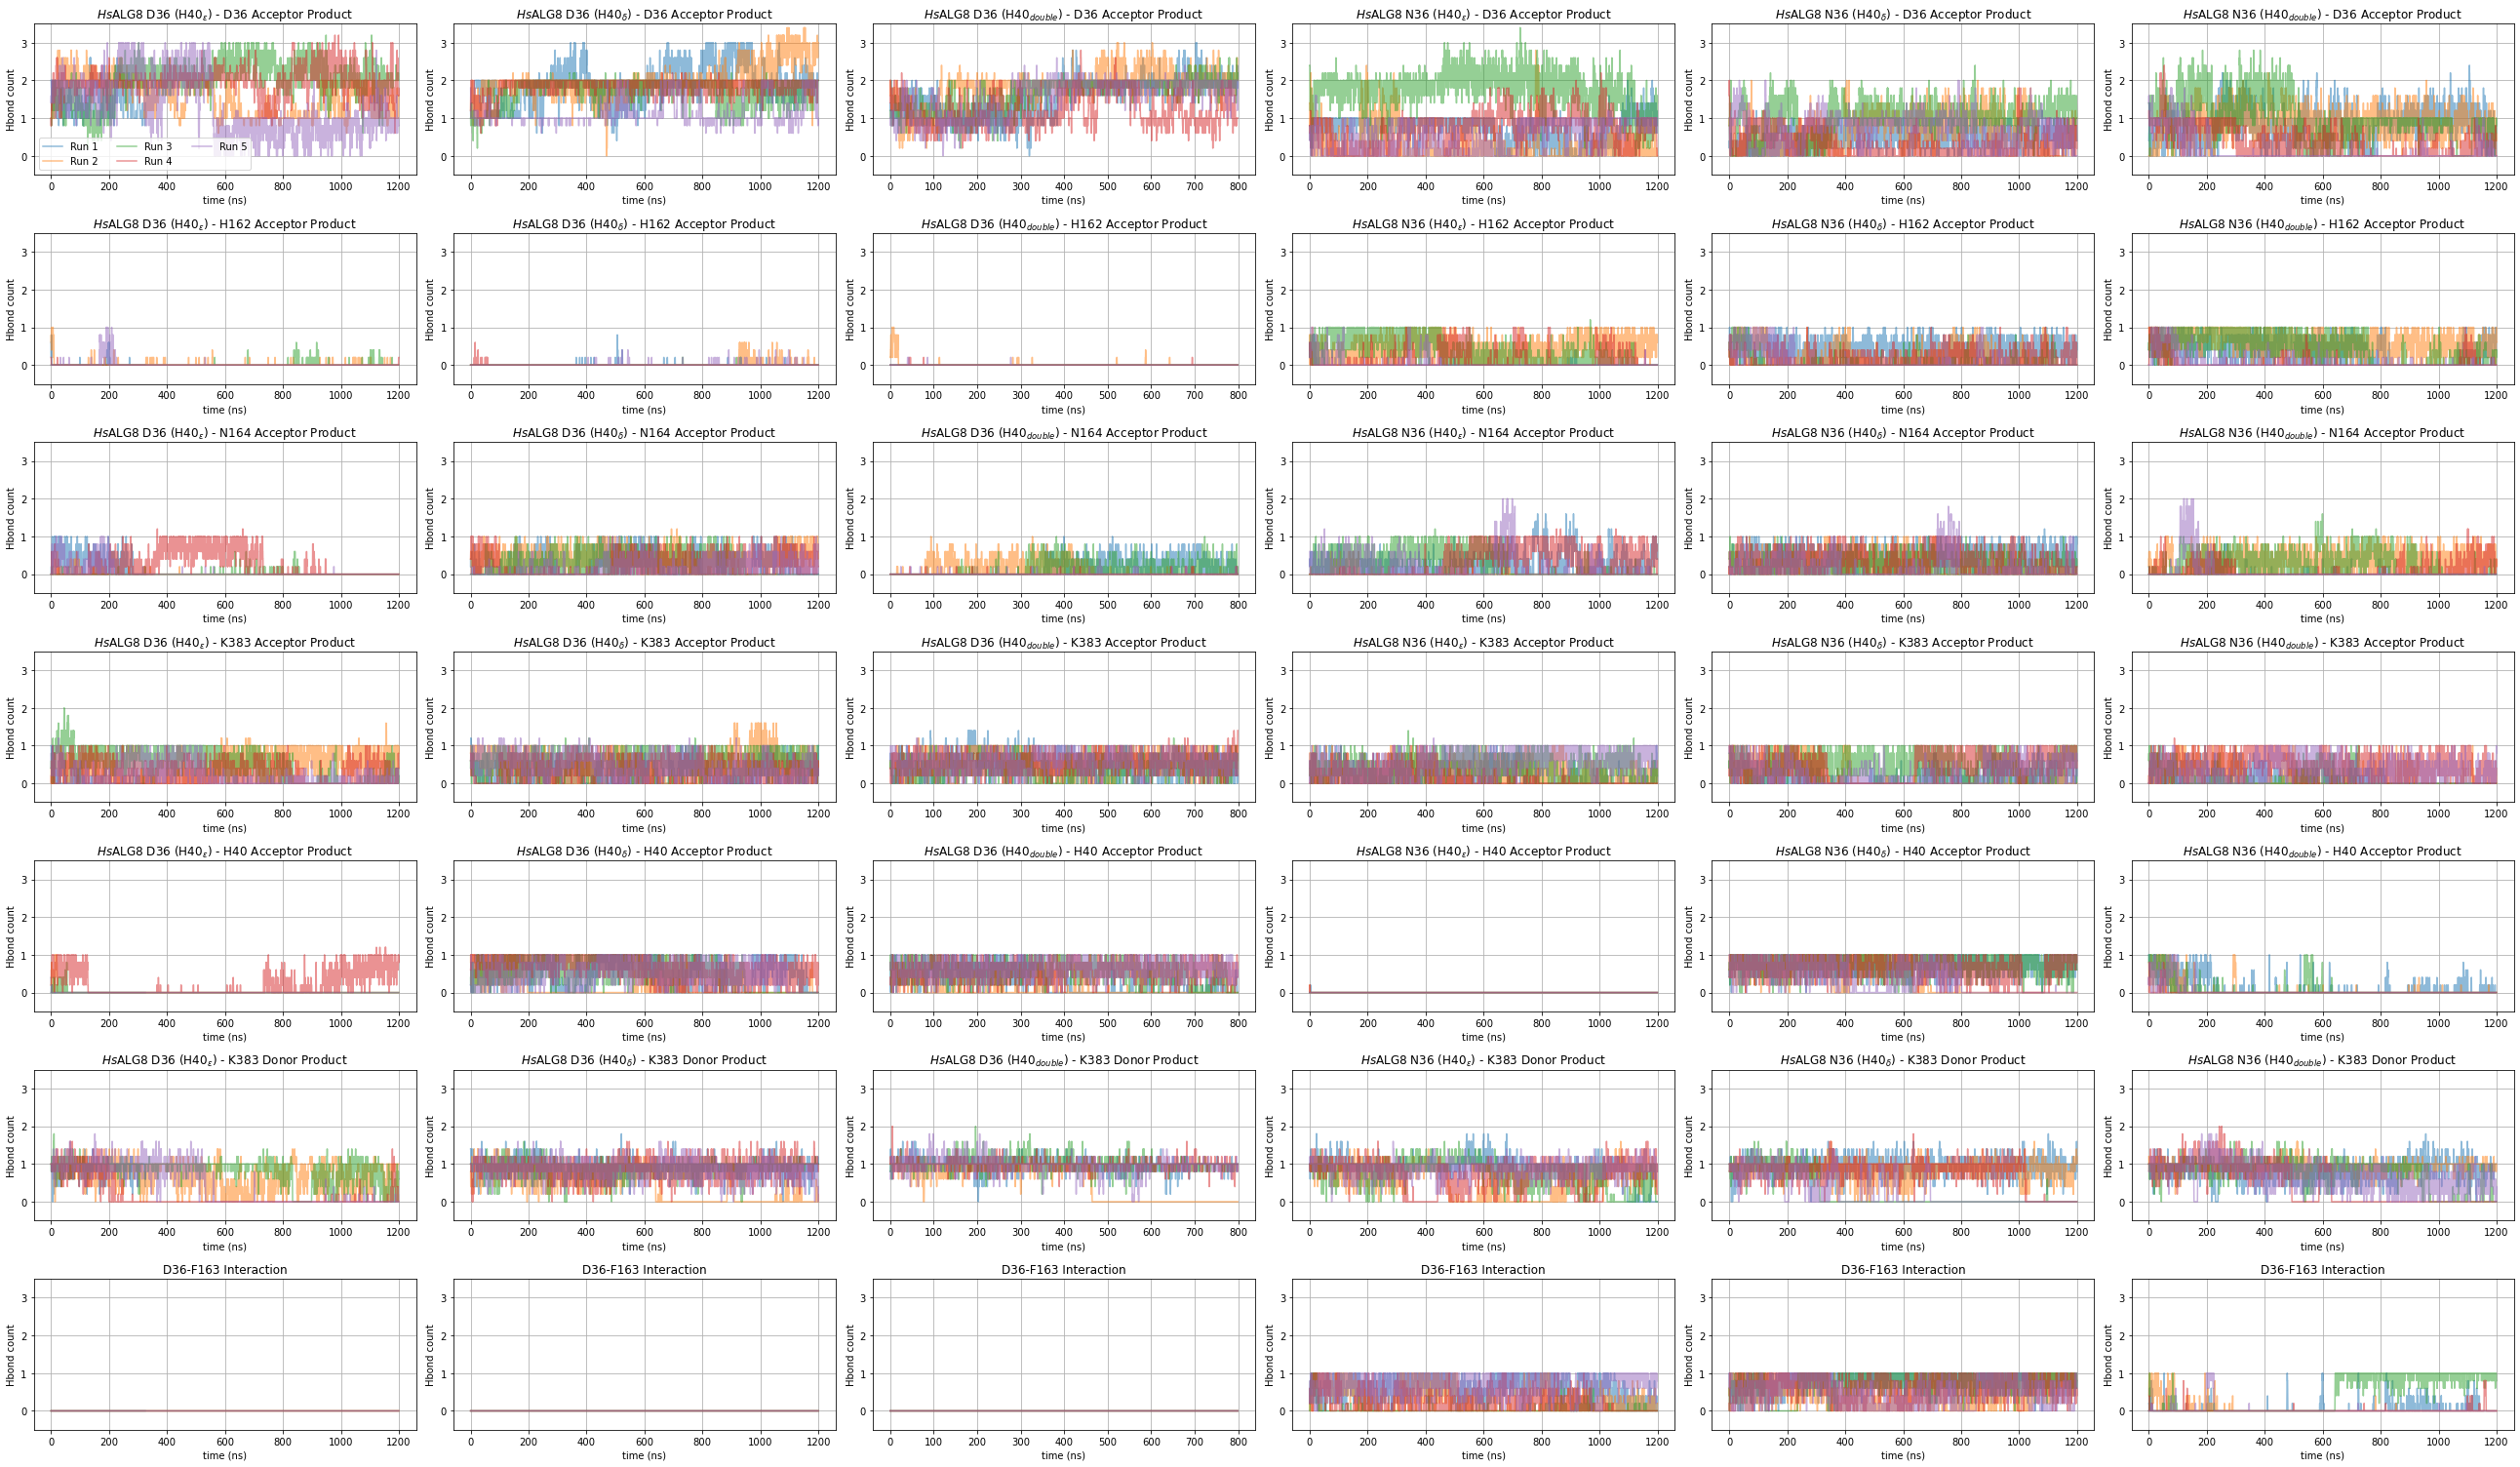

In [63]:
# AS-D82 distance
fig, axs = plt.subplots((4+2+1),(len(object_lists)),figsize=(6*len(object_lists),(4+2+1)*3))
ylim = [-0.5,3.5]
xlabel = 'time (ns)'
ylabel = 'Hbond count'
sliding_window = 5
discard_ratio = 0.1

for i_object_list, object_list in enumerate(object_lists):
    for i_rec, recname in enumerate(object_list[0].rec_name[:4]):
        discard_index = int(len(object_list[0].pro_rmsd)*discard_ratio)
        
        ax = axs[i_rec,i_object_list]
        for i_obj, obj in enumerate(object_list):
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
            y = sliding_average(obj.protein_substrates_bonds[0,i_rec],window_size=sliding_window)
            ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        ax.set_title(object_names[i_object_list]+' - '+recname+' Acceptor Product')
    # N164 with DP
    ax = axs[4,i_object_list]
    for i_obj, obj in enumerate(object_list):
        recname = obj.rec_name[7]
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(obj.protein_substrates_bonds[0,7],window_size=sliding_window)
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        ax.set_title(object_names[i_object_list]+' - '+recname+' Acceptor Product')

    # K383 with DP
    ax = axs[5,i_object_list]
    for i_obj, obj in enumerate(object_list):
        recname = obj.rec_name[3]
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(obj.protein_substrates_bonds[1,3],window_size=sliding_window)
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        ax.set_title(object_names[i_object_list]+' - '+recname+' Donor Product')

    # D36/N36 with F163
    ax = axs[6,i_object_list]
    for i_obj, obj in enumerate(object_list):
        recname = obj.rec_name[3]
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(obj.protein_inter_hbonds[0,8],window_size=sliding_window)
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        ax.set_title(f'{obj.rec_name[0]}-{obj.rec_name[8]} Interaction')
        # ax.vlines(x[discard_index], ymin=ylim[0], ymax=ylim[1], color='gray', linestyle='--', label='Discarded frames')

axs[0][0].legend(ncol=3)
for ax in axs.flatten():
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid()
plt.tight_layout()
filename = figdir+'/hbond_individual.png'
plt.savefig(filename, dpi=300)


    

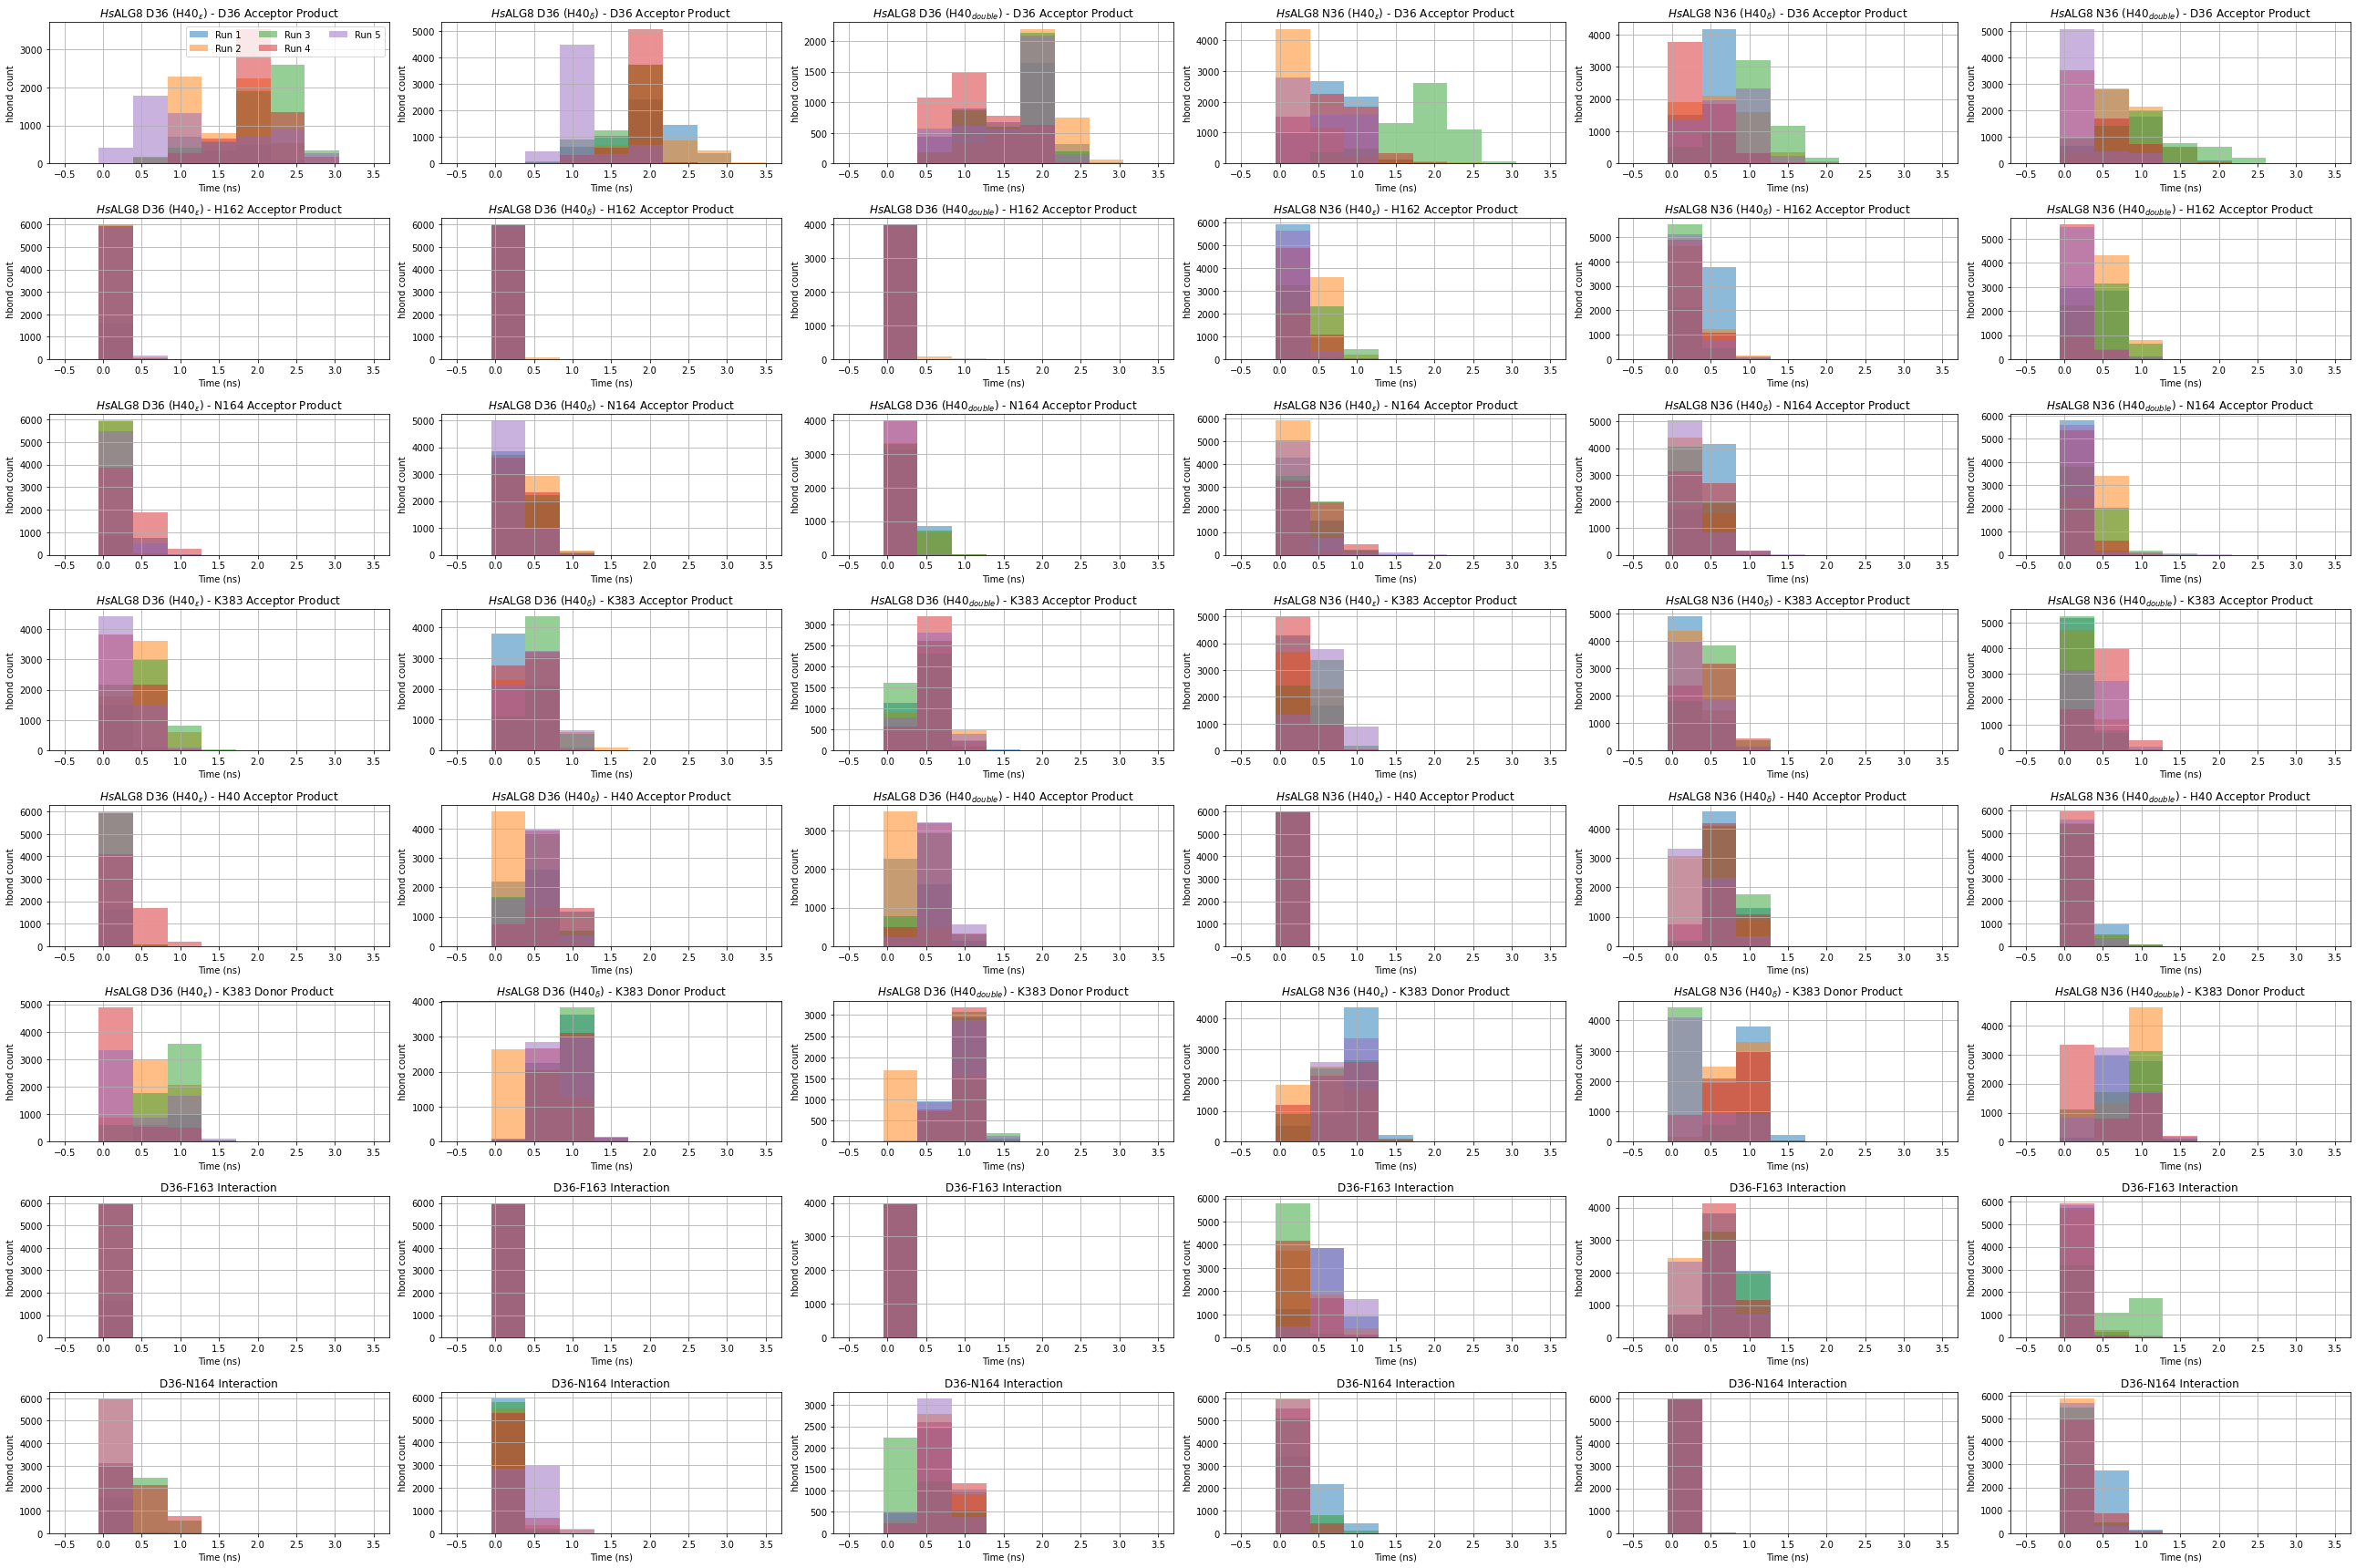

In [64]:
# AS-D82 distance
fig, axs = plt.subplots((4+2+2),(len(object_lists)),figsize=(6*len(object_lists),(4+2+2)*3))
ylim = [-0.5,3.5]
xlabel = 'Hbond'
ylabel = 'Count'
sliding_window = 5
discard_ratio = 0.2

for i_object_list, object_list in enumerate(object_lists):
    for i_rec, recname in enumerate(object_list[0].rec_name[:4]):
        discard_index = int(len(object_list[0].pro_rmsd)*discard_ratio)

        ax = axs[i_rec,i_object_list]
        for i_obj, obj in enumerate(object_list):
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
            y = sliding_average(obj.protein_substrates_bonds[0,i_rec],window_size=sliding_window)
            ax.hist(y, bins = np.linspace(ylim[0],ylim[1],10), label = f'Run {i_obj+1}',alpha=0.5)
        # ax.vlines(x[discard_index], ymin=ylim[0], ymax=ylim[1], color='gray', linestyle='--', label='Discarded frames')
        ax.set_title(object_names[i_object_list]+' - '+recname+' Acceptor Product')
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel(r'hbond count')
        ax.grid()
    # N164 with DP
    ax = axs[4,i_object_list]
    for i_obj, obj in enumerate(object_list):
        recname = obj.rec_name[7]
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(obj.protein_substrates_bonds[0,7],window_size=sliding_window)
        ax.hist(y, bins = np.linspace(ylim[0],ylim[1],10), label = f'Run {i_obj+1}',alpha=0.5)
        ax.set_title(object_names[i_object_list]+' - '+recname+' Acceptor Product')
        # ax.vlines(x[discard_index], ymin=ylim[0], ymax=ylim[1], color='gray', linestyle='--', label='Discarded frames')
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel(r'hbond count')
        ax.grid()
    # K383 with DP
    ax = axs[5,i_object_list]
    for i_obj, obj in enumerate(object_list):
        recname = obj.rec_name[3]
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(obj.protein_substrates_bonds[1,3],window_size=sliding_window)
        ax.hist(y, bins = np.linspace(ylim[0],ylim[1],10), label = f'Run {i_obj+1}',alpha=0.5)
        ax.set_title(object_names[i_object_list]+' - '+recname+' Donor Product')
        # ax.vlines(x[discard_index], ymin=ylim[0], ymax=ylim[1], color='gray', linestyle='--', label='Discarded frames')
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel(r'hbond count')
        ax.grid()
    # D36/N36 with F163
    ax = axs[6,i_object_list]
    for i_obj, obj in enumerate(object_list):
        recname = obj.rec_name[3]
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(obj.protein_inter_hbonds[0,8],window_size=sliding_window)
        ax.hist(y, bins = np.linspace(ylim[0],ylim[1],10), label = f'Run {i_obj+1}',alpha=0.5)
        ax.set_title(f'{obj.rec_name[0]}-{obj.rec_name[8]} Interaction')
        # ax.vlines(x[discard_index], ymin=ylim[0], ymax=ylim[1], color='gray', linestyle='--', label='Discarded frames')
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel(r'hbond count')
        ax.grid()
    # D36/N36 with N154
    ax = axs[7,i_object_list]
    for i_obj, obj in enumerate(object_list):
        recname = obj.rec_name[3]
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(obj.protein_inter_hbonds[0,2],window_size=sliding_window)
        ax.hist(y, bins = np.linspace(ylim[0],ylim[1],10), label = f'Run {i_obj+1}',alpha=0.5)
        ax.set_title(f'{obj.rec_name[0]}-{obj.rec_name[2]} Interaction')
        # ax.vlines(x[discard_index], ymin=ylim[0], ymax=ylim[1], color='gray', linestyle='--', label='Discarded frames')
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel(r'hbond count')
        ax.grid()
axs[0][0].legend(ncol=3)

plt.tight_layout()
filename = figdir+'/hbond_individual_distribution.png'
plt.savefig(filename, dpi=300)


    

In [65]:
width = 0.15
show_AS_hbond_names = ['D36', 'H40', 'D66', 'Donor Product']
receptor_indices    = [0, 7, 6]
discard_ratio = 0.1

rows = []

for i_object_list, object_list in enumerate(object_lists):
    row = {}

    # Hbonds with protein
    for i_rec, rec_id in enumerate(receptor_indices):
        occupancies = []
        for obj in object_list:
            hbonds = obj.protein_substrates_bonds[0, rec_id]
            discard_index = int(len(hbonds) * discard_ratio)
            denom = (len(hbonds) - discard_index)
            occ = np.sum(hbonds[discard_index:]) / denom if denom > 0 else np.nan
            occupancies.append(occ)

        row[show_AS_hbond_names[i_rec]] = np.mean(occupancies)

    # Hbonds with donor sugar (intra)
    ds_occupancies = []
    for obj in object_list:
        hbonds = obj.intra_hydrogen_bonds
        discard_index = int(len(hbonds) * discard_ratio)
        denom = (len(hbonds) - discard_index)
        occ = np.sum(hbonds[discard_index:]) / denom if denom > 0 else np.nan
        ds_occupancies.append(occ)

    row['Donor Product'] = np.mean(ds_occupancies)
    row['system'] = object_names[i_object_list]

    rows.append(row)
df = pd.DataFrame(rows).set_index('system')


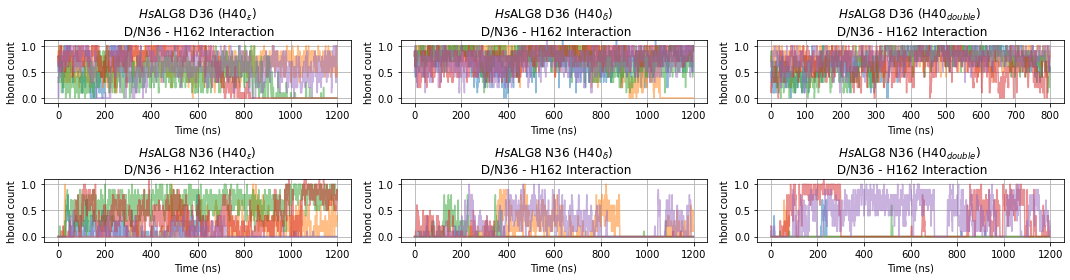

In [66]:
# N36 - F163/H162
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
axs = axs.flatten()
ylim = [-0.1,1.1]
xlabel = 'Hbond'
ylabel = 'Count'
sliding_window = 10
discard_ratio = 0.1
N36_index = 0
H162_index = 1
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list]
    for i_obj, obj in enumerate(object_list):
        recname = obj.rec_name[H162_index]
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(obj.protein_inter_hbonds[N36_index,H162_index],window_size=sliding_window)
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        ax.grid()
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel(r'hbond count')
        ax.set_ylim(ylim)
        ax.set_title(f'{object_names[i_object_list]} \n D/N36 - H162 Interaction')
# axs.legend(ncol=3)
plt.tight_layout()
filename = figdir+'/DN36-H162_hbond.png'
plt.savefig(filename, dpi=300)
        

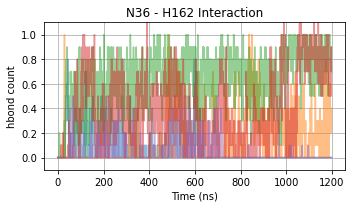

In [67]:
# N36 - F163/H162
fig, axs = plt.subplots(1,1,figsize=(5,3))
ylim = [-0.1,1.1]
xlabel = 'Hbond'
ylabel = 'Count'
sliding_window = 10
discard_ratio = 0.1
N36_index = 0
H162_index = 1
i_object_list = 3
object_list = object_lists[i_object_list]
ax = axs
for i_obj, obj in enumerate(object_list):
    recname = obj.rec_name[H162_index]
    x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
    y = sliding_average(obj.protein_inter_hbonds[N36_index,H162_index],window_size=sliding_window)
    ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
    ax.grid()
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'hbond count')
    ax.set_ylim(ylim)
    ax.set_title(f'N36 - H162 Interaction')
# axs.legend(ncol=3)
plt.tight_layout()
filename = figdir+'/N36-H162_hbond.png'
plt.savefig(filename, dpi=300)
        

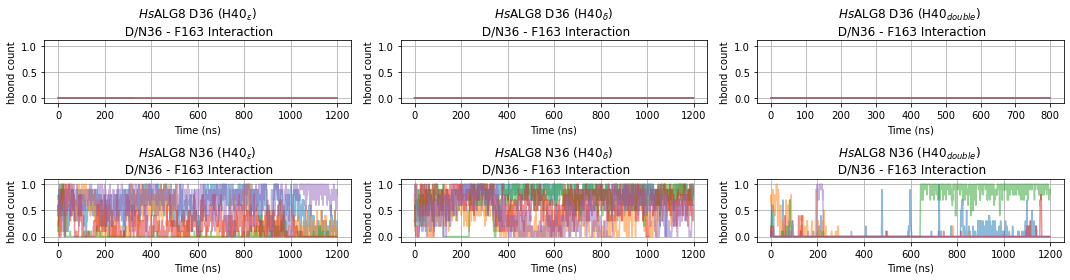

In [68]:
# N36 - F163/H162
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
axs = axs.flatten()
ylim = [-0.1,1.1]
xlabel = 'Hbond'
ylabel = 'Count'
sliding_window = 10
discard_ratio = 0.1
N36_index = 0
H162_index = 1
F163_index = 8
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list]
    for i_obj, obj in enumerate(object_list):
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        recname = obj.rec_name[F163_index]
        y = sliding_average(obj.protein_inter_hbonds[N36_index,F163_index],window_size=sliding_window)
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'hbond count')
    ax.set_ylim(ylim)
    ax.grid()
    ax.set_title(f'{object_names[i_object_list]} \n D/N36 - F163 Interaction')

plt.tight_layout()
filename = figdir+'/N36_F163_interactions.png'
plt.savefig(filename, dpi=300)
        

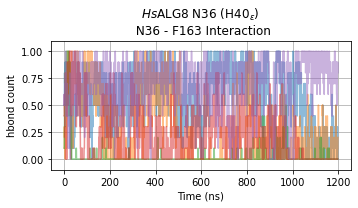

In [69]:
# N36 - F163/H162
fig, axs = plt.subplots(1,1,figsize=(5,3))
ylim = [-0.1,1.1]
xlabel = 'Hbond'
ylabel = 'Count'
sliding_window = 10
discard_ratio = 0.1
N36_index = 0
H162_index = 1
i_object_list = 3
object_list = object_lists[i_object_list]
ax = axs
for i_obj, obj in enumerate(object_list):
    x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
    recname = obj.rec_name[F163_index]
    y = sliding_average(obj.protein_inter_hbonds[N36_index,F163_index],window_size=sliding_window)
    ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
ax.set_xlabel('Time (ns)')
ax.set_ylabel(r'hbond count')
ax.set_ylim(ylim)
ax.grid()
ax.set_title(f'{object_names[i_object_list]} \n N36 - F163 Interaction')

plt.tight_layout()
filename = figdir+'/N36_F163_interactions.png'
plt.savefig(filename, dpi=300)
        

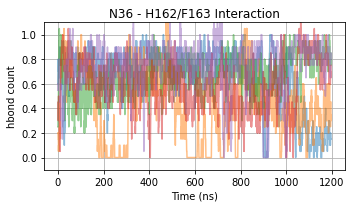

In [70]:
# N36 - F163/H162
fig, axs = plt.subplots(1,1,figsize=(5,3))
ylim = [-0.1,1.1]
xlabel = 'Hbond'
ylabel = 'Count'
sliding_window = 20
discard_ratio = 0.1
N36_index = 0
H162_index = 1
i_object_list = 3
object_list = object_lists[i_object_list]
ax = axs
for i_obj, obj in enumerate(object_list):
    x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
    recname = obj.rec_name[F163_index]
    y1 = sliding_average(obj.protein_inter_hbonds[N36_index,F163_index],window_size=sliding_window)
    y2 = sliding_average(obj.protein_inter_hbonds[N36_index,H162_index],window_size=sliding_window)
    y = (y1 + y2)
    ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
ax.set_xlabel('Time (ns)')
ax.set_ylabel(r'hbond count')
ax.set_ylim(ylim)
ax.grid()
ax.set_title(f'N36 - H162/F163 Interaction')

plt.tight_layout()
filename = figdir+'/N36_H162_F163_interactions.png'
plt.savefig(filename, dpi=300)
        

# last sugar correlation with D36 zaxis

AttributeError: 'ALG_simulations' object has no attribute 'ele_density'

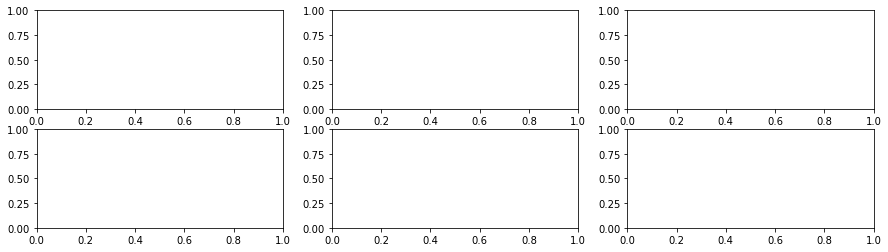

In [71]:
# N36 - F163/H162
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
axs = axs.flatten()
z_lipid = [-17.6, 17.6]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list]
    for i_obj, obj in enumerate(object_list):
        x, E, _ = obj.ele_density.T
        ax.plot(x,E, label = f'Run {i_obj+1}',alpha=0.5)
    ax.set_title(f'{object_names[i_object_list]} \n Electrostatic Density Profile')
    ax.set_xlabel('z-position (nm)')
    ax.set_ylabel(r'Electrostatic Density')
    ax.grid()
for ax in axs:
    for z in z_lipid:
        ax.vlines(z, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='red', linestyle='--', alpha=1)
plt.tight_layout()
filename = figdir+'/Electrostatic_density_profile.png'
        

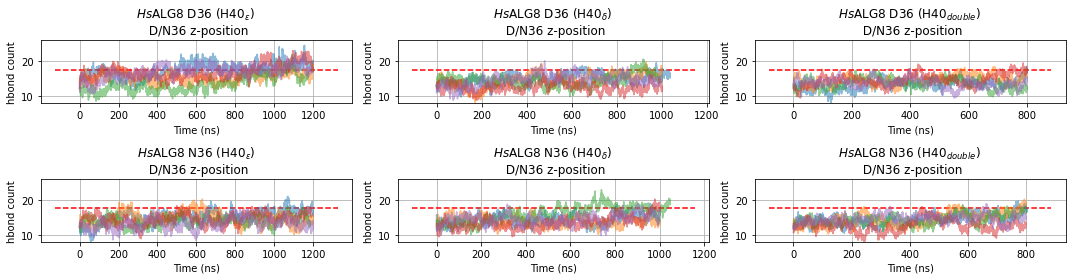

In [ ]:
# N36 - F163/H162
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
axs = axs.flatten()
ylim = [8,26]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list]
    for i_obj, obj in enumerate(object_list):
        y = obj.D36_z
        x = np.arange(0,len(y)*0.2,0.2)
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'hbond count')
    ax.grid()
    ax.set_ylim(ylim)
    ax.set_title(f'{object_names[i_object_list]} \n D/N36 z-position')
plt.tight_layout()
for ax in axs:
    for z in z_lipid:
        ax.hlines(z, xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red', linestyle='--', alpha=1)
filename = figdir+'/D36_z_position.png'
plt.savefig(filename, dpi=300)
# filename = figdir+'/N36_F163_interactions.png'
# plt.savefig(filename, dpi=300)


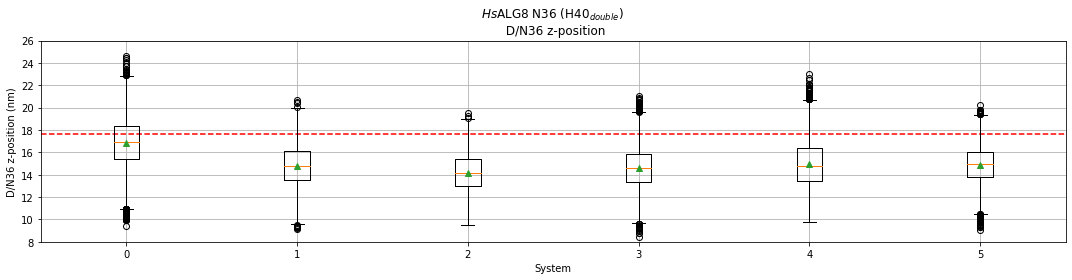

In [ ]:
# N36 - F163/H162
fig, ax = plt.subplots(1,1,figsize=(2.5*len(object_lists),4))
discard_frames = 2400
ylim = [8,26]
for i_object_list, object_list in enumerate(object_lists):
    z_total = []
    for i_obj, obj in enumerate(object_list):
        z = obj.D36_z
        mask = np.arange(0,len(z)) >= discard_frames
        z_total.append(z[mask])
    ax.boxplot(np.concatenate(z_total), positions=[i_object_list], showmeans=True)
ax.set_xlabel('System')
ax.set_ylabel(r'D/N36 z-position (nm)')
ax.set_xticks(np.arange(len(object_lists)))
ax.grid()
ax.set_ylim(ylim)
ax.set_title(f'{object_names[i_object_list]} \n D/N36 z-position')
plt.tight_layout()
for z in z_lipid:
    ax.hlines(z, xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red', linestyle='--', alpha=1)
filename = figdir+'/D36_z_position.png'
plt.savefig(filename, dpi=300)
# filename = figdir+'/N36_F163_interactions.png'
# plt.savefig(filename, dpi=300)


## Correlation with AS RMSD

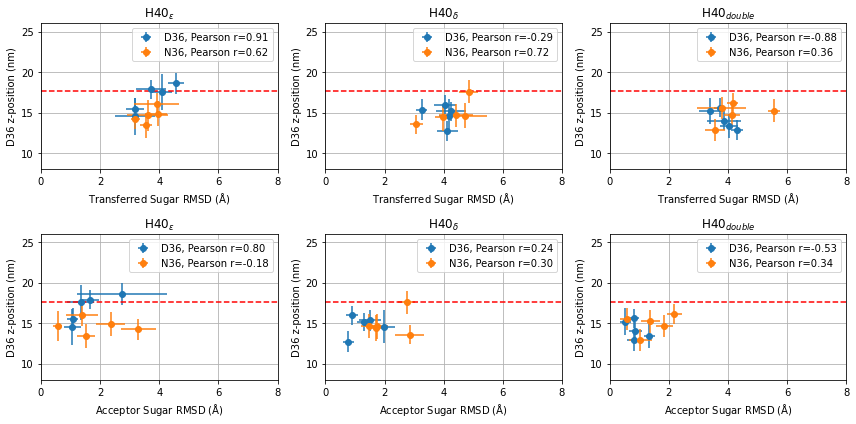

In [ ]:
discard_frames = 2400
xlim = [0, 8]
fig, axs = plt.subplots(2,3,figsize=(12,6))
for i_object_list, object_list in enumerate(object_lists):
    
    DS_data = np.zeros([len(object_list), 2]) # avg, std
    AS_data = np.zeros_like(DS_data)
    D36_data = np.zeros_like(DS_data)
    for i_obj, obj in enumerate(object_list):
        # D36_z
        D36_z = obj.D36_z[discard_frames:]
        D36_data[i_obj] = np.mean(D36_z), np.std(D36_z)
        # AS
        AS = obj.A_sugar_rmsd[discard_frames:]
        AS_data[i_obj] = np.mean(AS), np.std(AS)
        # DS
        DS_rmsd = obj.DS_rmsd[discard_frames:]
        DS_data[i_obj] = np.mean(DS_rmsd), np.std(DS_rmsd)
        
    # plot AS vs D36_z
    ax = axs[:,i_object_list%3]
    pearson_r = np.corrcoef(DS_data[:,0], D36_data[:,0])[0,1]
    ax[0].errorbar(DS_data[:,0], D36_data[:,0], xerr=DS_data[:,1], yerr=D36_data[:,1], fmt='o', label=f"{object_names[i_object_list].split(' ')[1]}, Pearson r={pearson_r:.2f}")
    pearson_r = np.corrcoef(AS_data[:,0], D36_data[:,0])[0,1]
    ax[1].errorbar(AS_data[:,0], D36_data[:,0], xerr=AS_data[:,1], yerr=D36_data[:,1], fmt='o', label=f"{object_names[i_object_list].split(' ')[1]}, Pearson r={pearson_r:.2f}")
    ax[0].set_title(object_names[i_object_list].split(' ')[2][1:-1])
    ax[1].set_title(object_names[i_object_list].split(' ')[2][1:-1])
    ax[0].set_xlabel(r'Transferred Sugar RMSD ($\rm \AA$)')
    ax[1].set_xlabel(r'Acceptor Sugar RMSD ($\rm \AA$)')   
    
for ax in axs.flatten():
    ax.hlines(z_lipid[1], xmin=xlim[0], xmax=xlim[1] , color='red', linestyle='--', alpha=1)
    ax.grid()
    ax.set_ylabel('D36 z-position (nm)')
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.legend()
plt.tight_layout()

# plt.legend()

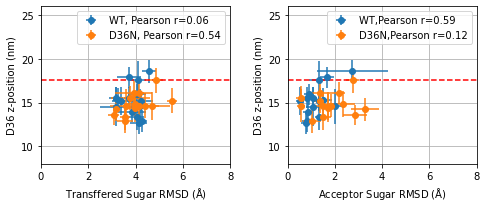

In [ ]:
discard_frames = 2400
xlim = [0, 8]
fig, axs = plt.subplots(1,2,figsize=(7,3))
DS_data = np.zeros([6, 5, 2]) # Glc/Man, replicates, avg/std
AS_data = np.zeros_like(DS_data)
D36_data = np.zeros_like(DS_data)
for i_object_list, object_list in enumerate(object_lists):
    for i_obj, obj in enumerate(object_list):
        # D36_z
        D36_z = obj.D36_z[discard_frames:]
        D36_data[i_object_list, i_obj] = np.mean(D36_z), np.std(D36_z)
        # AS
        AS = obj.A_sugar_rmsd[discard_frames:]
        AS_data[i_object_list, i_obj] = np.mean(AS), np.std(AS)
        # DS
        DS_rmsd = obj.DS_rmsd[discard_frames:]
        DS_data[i_object_list, i_obj] = np.mean(DS_rmsd), np.std(DS_rmsd)
        
D36_data = D36_data.reshape(2,15,2)
AS_data = AS_data.reshape(2,15,2)
DS_data = DS_data.reshape(2,15,2)

for mutant_name in range(2):
    mutant_label = 'WT' if mutant_name ==0 else 'D36N'
    pearson_r = np.corrcoef(DS_data[mutant_name,:,0], D36_data[mutant_name,:,0])[0,1]
    axs[0].errorbar(DS_data[mutant_name,:,0], D36_data[mutant_name,:,0], xerr=DS_data[mutant_name,:,1], yerr=D36_data[mutant_name,:,1], fmt='o', label=f"{mutant_label}, Pearson r={pearson_r:.2f}")
    pearson_r = np.corrcoef(AS_data[mutant_name,:,0], D36_data[mutant_name,:,0])[0,1]
    axs[1].errorbar(AS_data[mutant_name,:,0], D36_data[mutant_name,:,0], xerr=AS_data[mutant_name,:,1], yerr=D36_data[mutant_name,:,1], fmt='o', label=f"{mutant_label},Pearson r={pearson_r:.2f}")
    axs[0].set_xlabel(r'Transffered Sugar RMSD ($\rm \AA$)')
    axs[1].set_xlabel(r'Acceptor Sugar RMSD ($\rm \AA$)')   

for ax in axs.flatten():
    ax.hlines(z_lipid[1], xmin=xlim[0], xmax=xlim[1] , color='red', linestyle='--', alpha=1)
    ax.grid()
    ax.set_ylabel('D36 z-position (nm)')
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.legend()
plt.tight_layout()

# plt.legend()

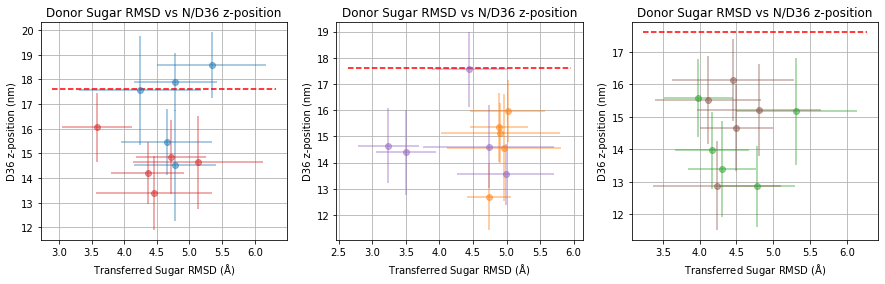

In [ ]:
discard_frames = 2400
fig, axs = plt.subplots(1,3,figsize=(15,4))
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list%3]
    for i_obj, obj in enumerate(object_list):
        AS_rmsd = obj.AS_rmsd[discard_frames:]
        AS_rmsd_avg, AS_rmsd_std = np.mean(AS_rmsd), np.std(AS_rmsd)
        D36_z = obj.D36_z[discard_frames:]
        D36_z_avg, D36_z_std = np.mean(D36_z), np.std(D36_z)
        ax.errorbar(AS_rmsd_avg, D36_z_avg, xerr=AS_rmsd_std, yerr=D36_z_std, fmt='o', label=f'{object_names[i_object_list]} Run {i_obj+1}', alpha=0.5, color=f'C{i_object_list}')
for ax in axs:
    ax.hlines(z_lipid[1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red', linestyle='--', alpha=1)
    ax.grid()
    ax.set_xlabel(r'Transferred Sugar RMSD ($\rm \AA$)')
    ax.set_ylabel('D36 z-position (nm)')
    ax.set_title('Donor Sugar RMSD vs N/D36 z-position')
# plt.legend()

## C sugar hbond

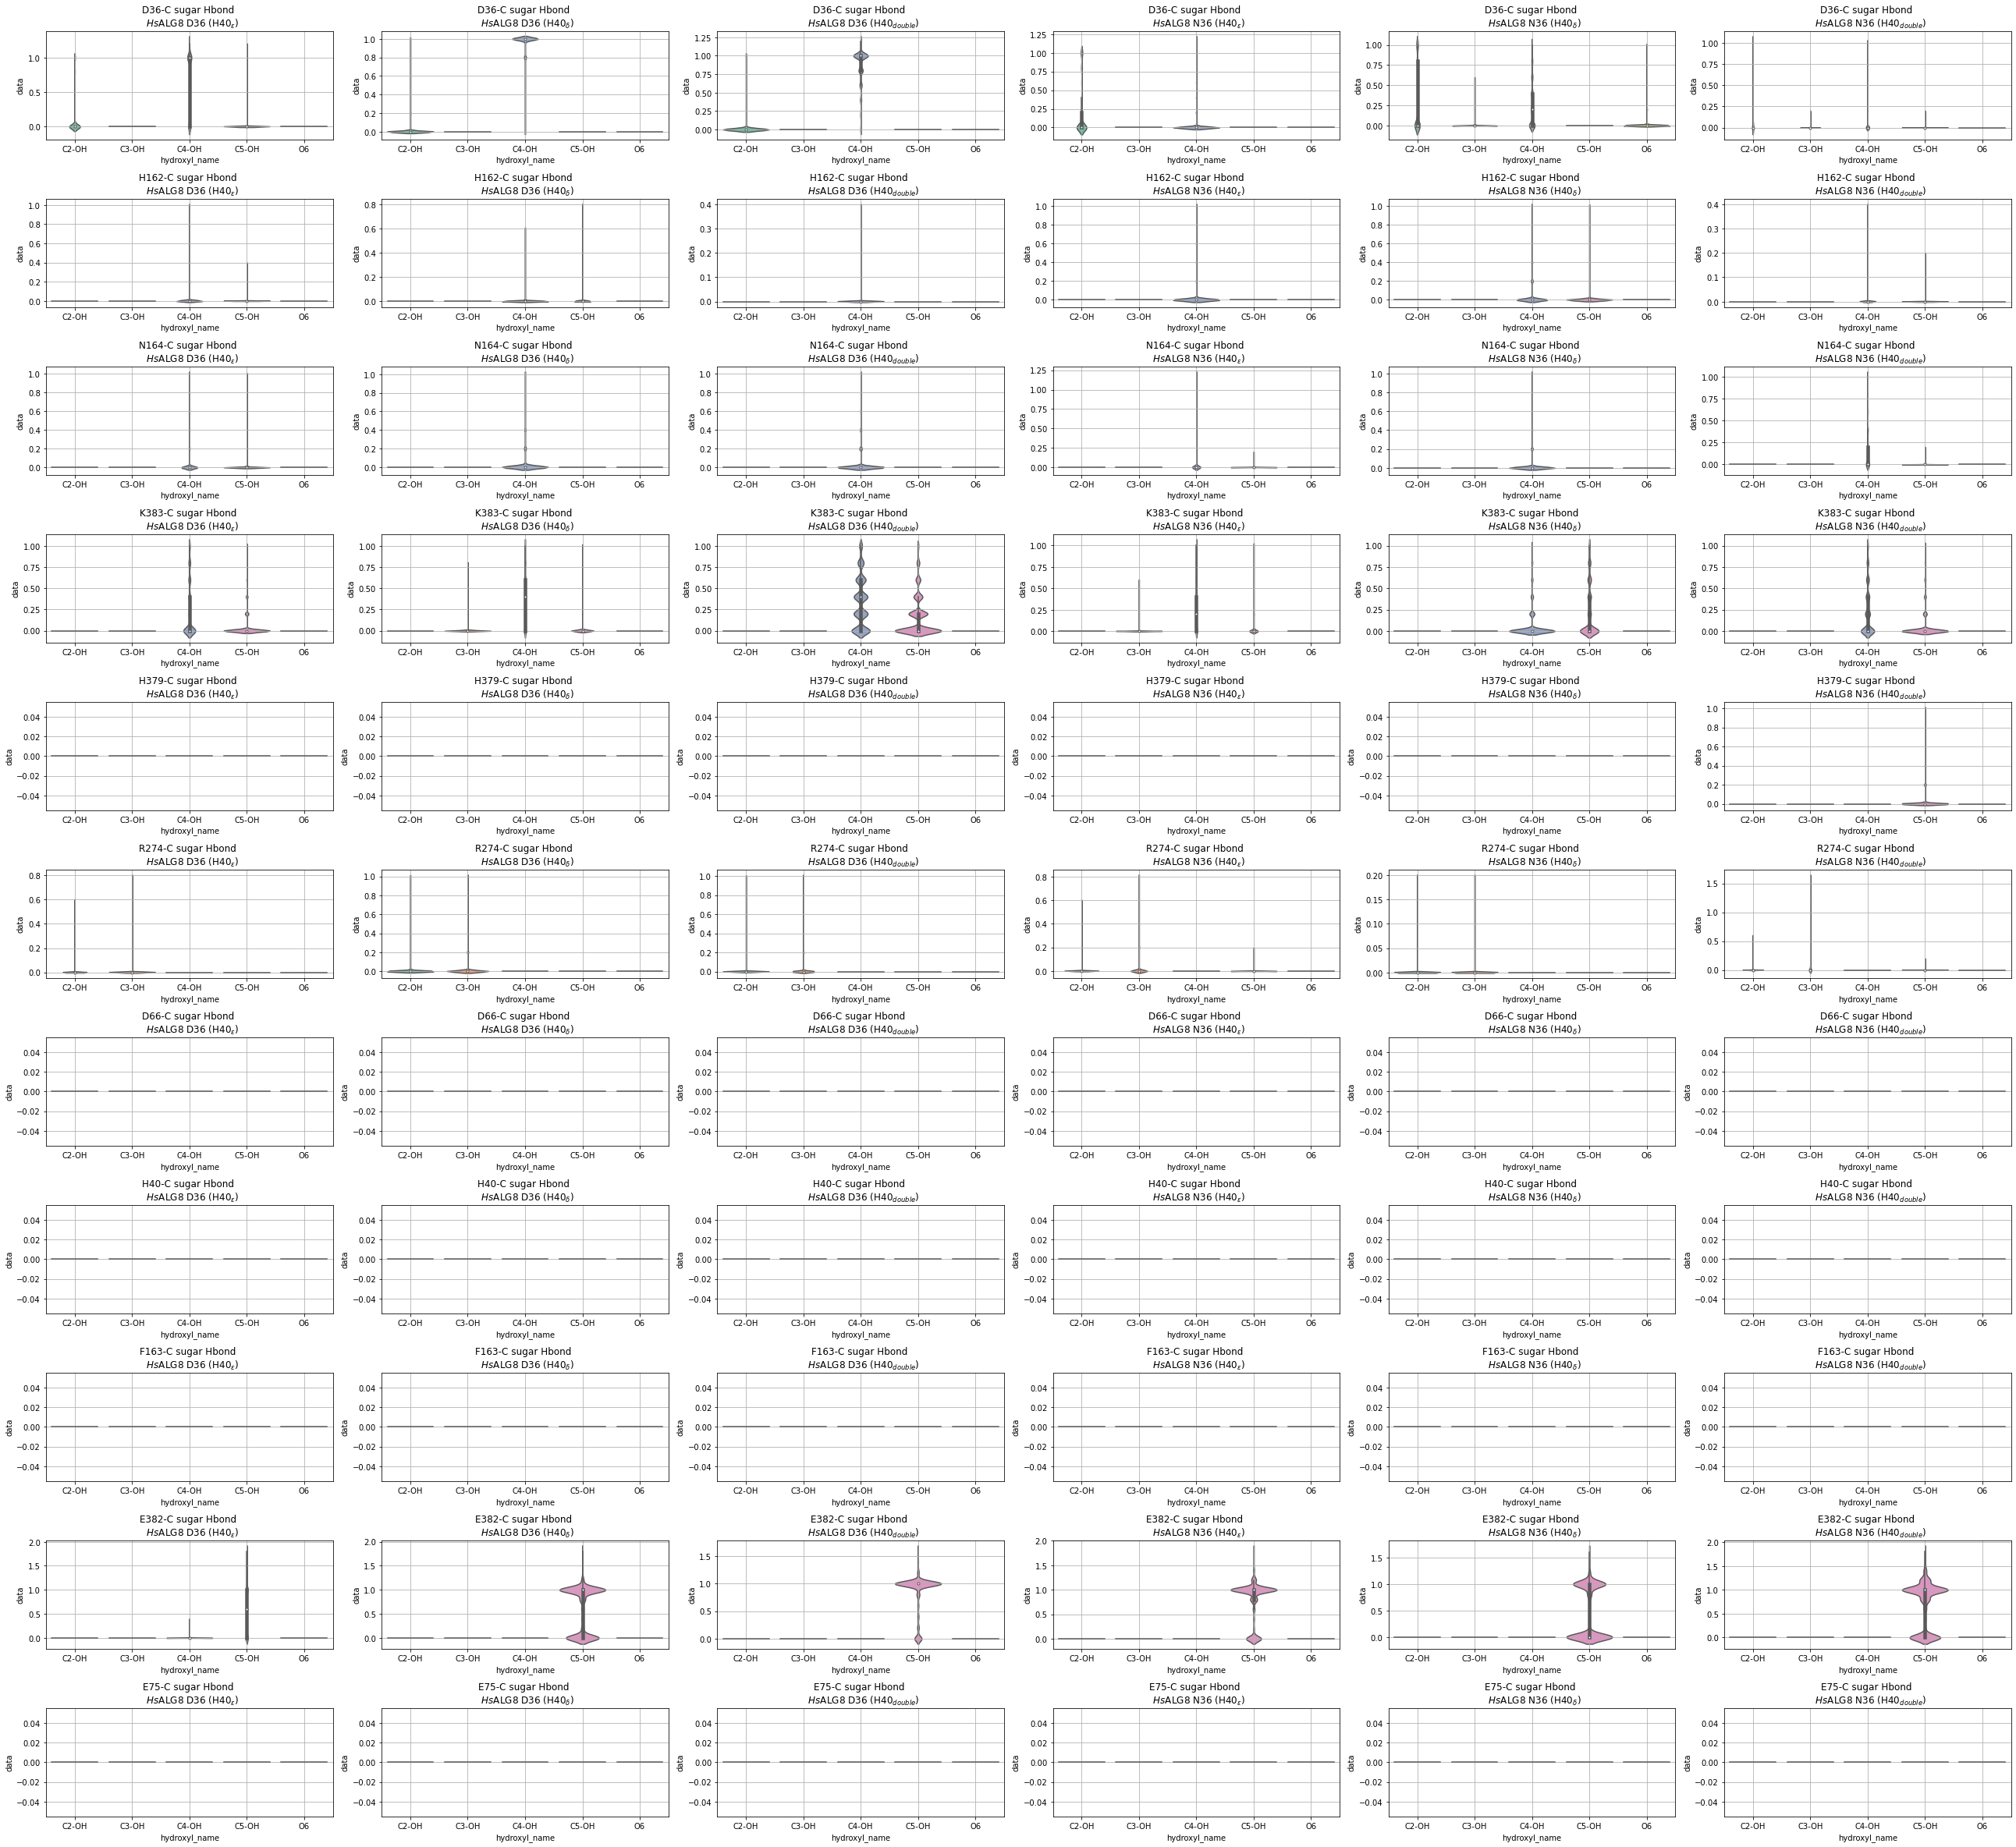

In [ ]:
fig, axs = plt.subplots(len(object_list[0].rec_name),len(object_lists),figsize=(6*len(object_lists),3*len(object_list[0].rec_name)))
sliding_window = 5
hydroxyl_names = ['C2-OH','C3-OH','C4-OH','C5-OH','O6']
for i_rec, recname in enumerate(object_list[0].rec_name):
    for i_object_list, object_list in enumerate(object_lists):
        df = pd.DataFrame()
        ax = axs[i_rec, i_object_list]
        for i_obj, obj in enumerate(object_list):
            df_ = pd.DataFrame(columns=['system']+hydroxyl_names)
            for i_hydroxyl, hydroxyl_name in enumerate(hydroxyl_names):
                df_['data'] = sliding_average(obj.C_sugar_hbond[i_hydroxyl,i_rec], window_size=sliding_window)
                df_['system'] = object_names[i_object_list]
                df_['hydroxyl_name'] = hydroxyl_name
                df = pd.concat([df, df_], ignore_index=True)
        sns.violinplot(data=df, x='hydroxyl_name', y='data', ax=ax, inner='box', palette='Set2')
        ax.set_title(f"{recname}-C sugar Hbond \n  {object_names[i_object_list]}")
        ax.grid()
plt.tight_layout()
filename = figdir+'Violin_Csugar_hbond.png'
plt.savefig(filename)


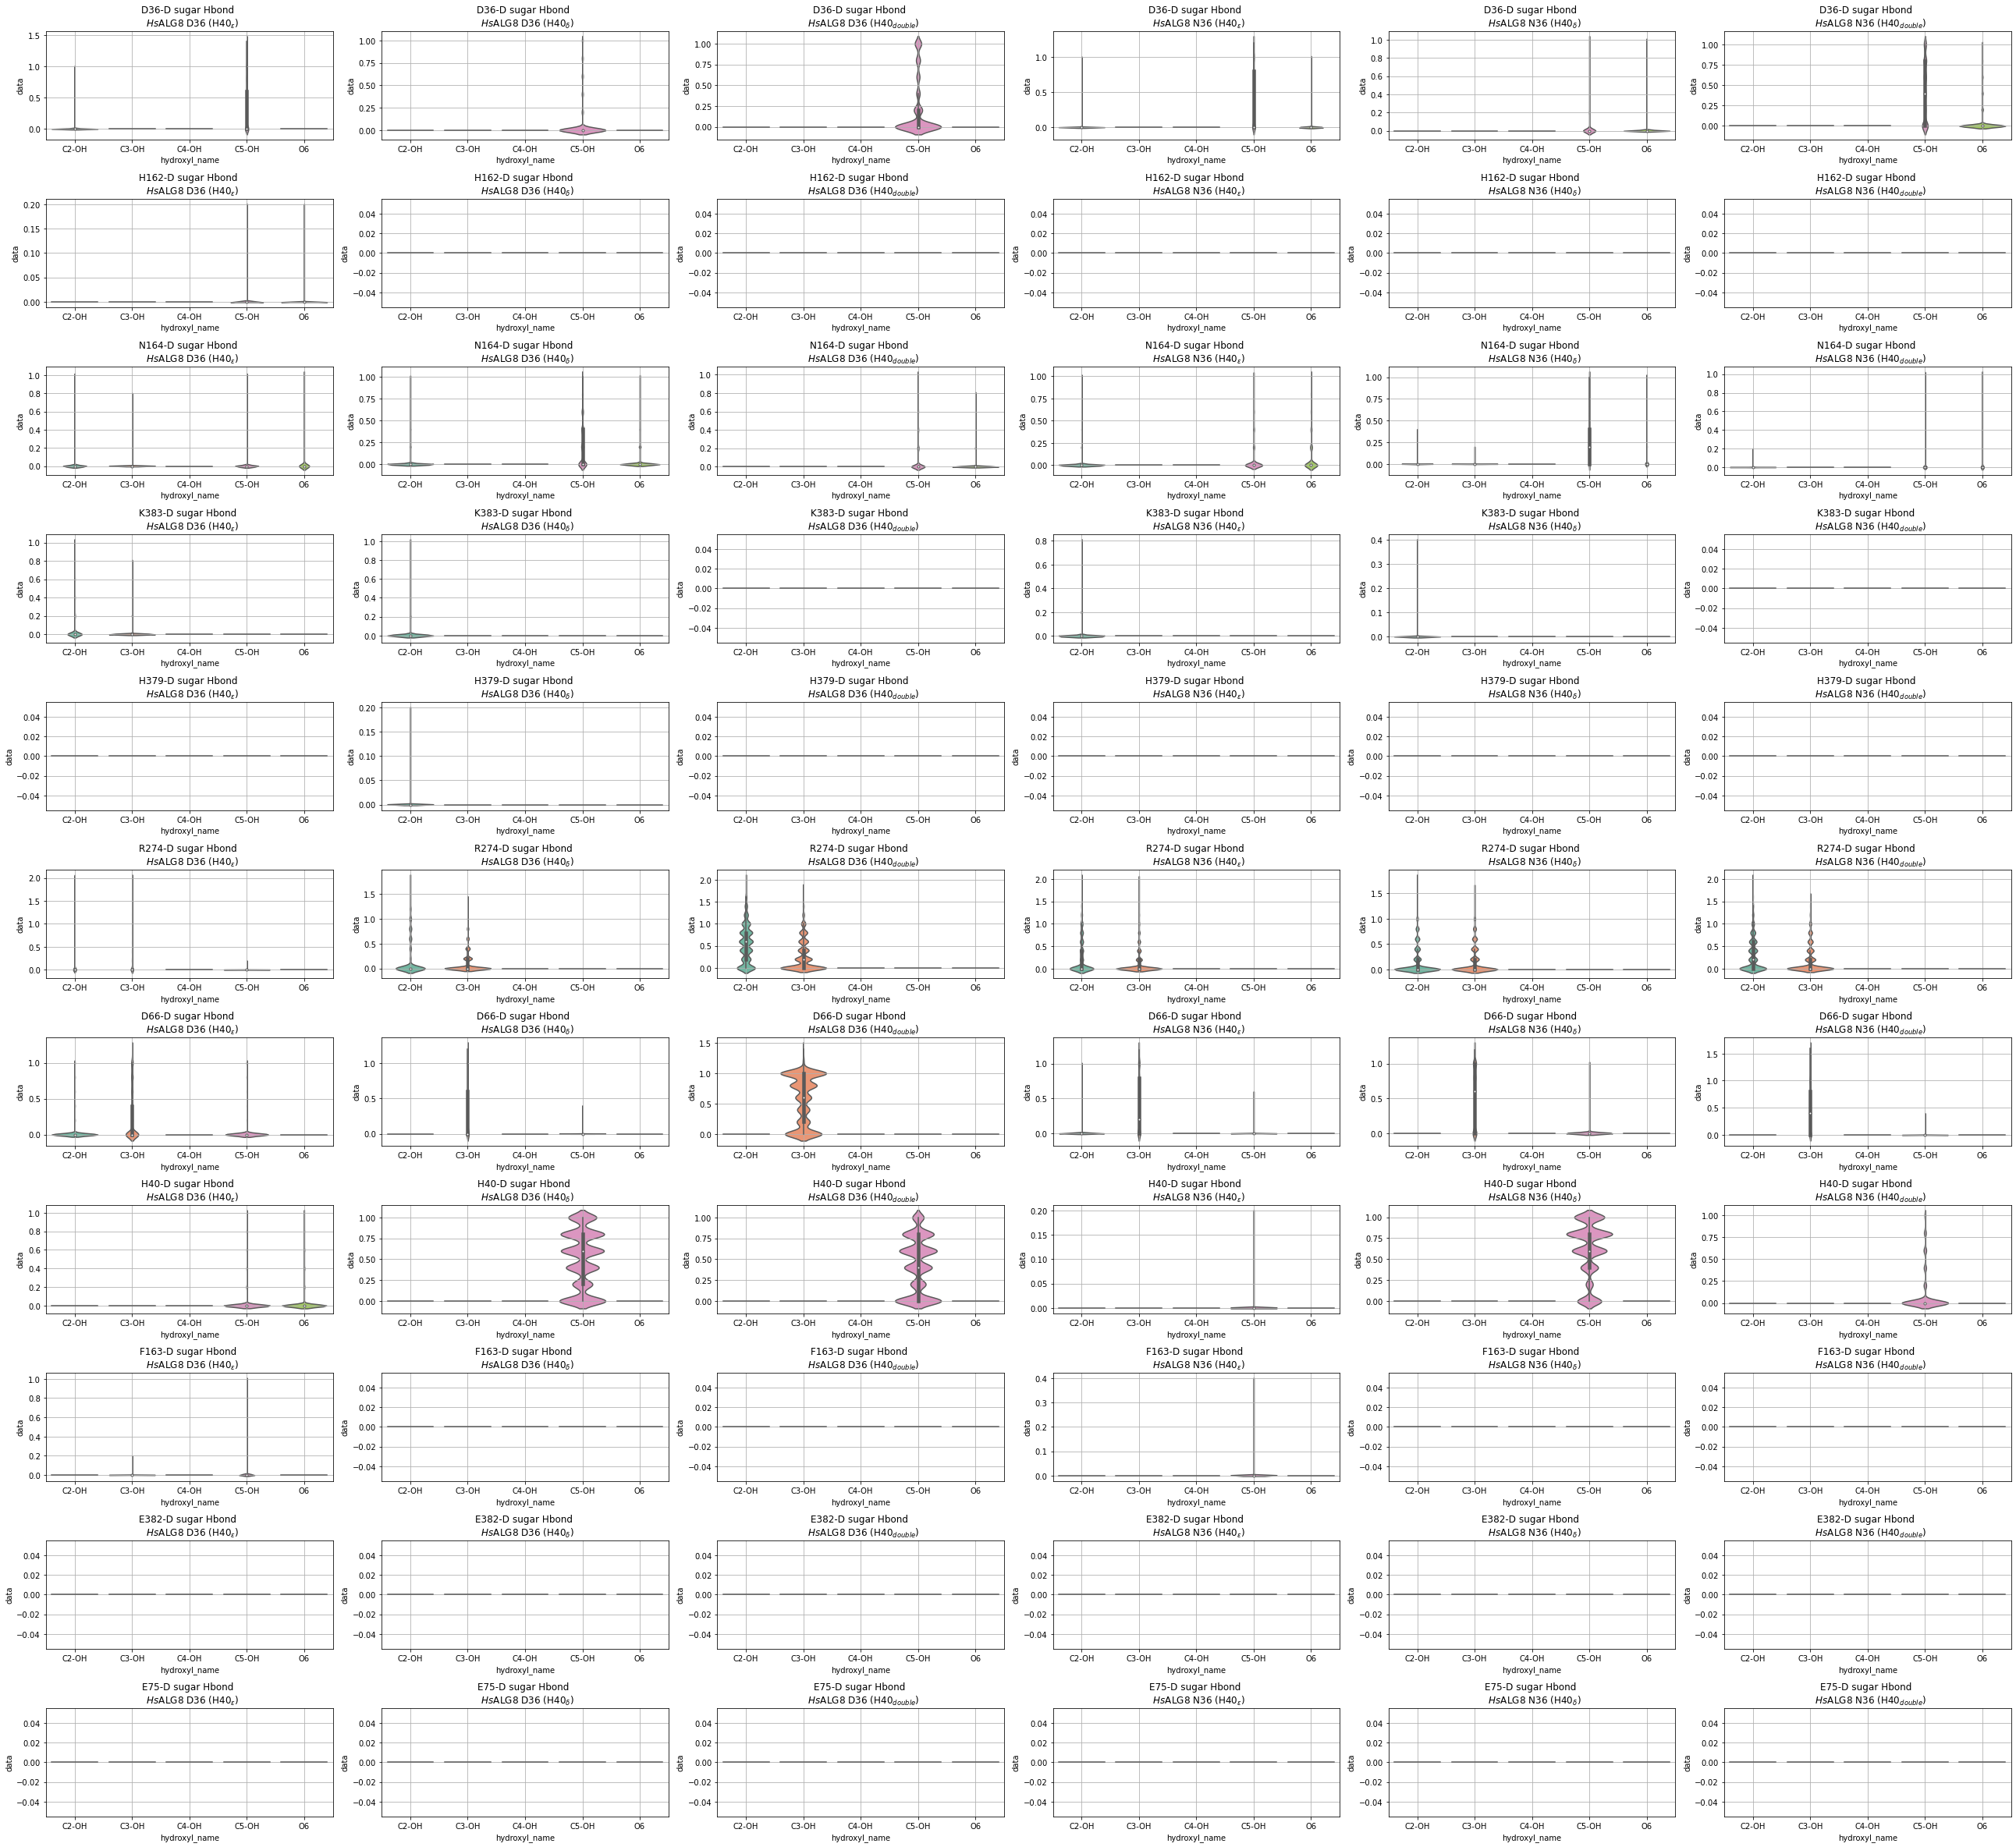

In [ ]:
fig, axs = plt.subplots(len(object_list[0].rec_name),len(object_lists),figsize=(6*len(object_lists),3*len(object_list[0].rec_name)))
sliding_window = 5
hydroxyl_names = ['C2-OH','C3-OH','C4-OH','C5-OH','O6']
for i_rec, recname in enumerate(object_list[0].rec_name):
    for i_object_list, object_list in enumerate(object_lists):
        df = pd.DataFrame()
        ax = axs[i_rec, i_object_list]
        for i_obj, obj in enumerate(object_list):
            df_ = pd.DataFrame(columns=['system']+hydroxyl_names)
            for i_hydroxyl, hydroxyl_name in enumerate(hydroxyl_names):
                df_['data'] = sliding_average(obj.D_sugar_hbond[i_hydroxyl,i_rec], window_size=sliding_window)
                df_['system'] = object_names[i_object_list]
                df_['hydroxyl_name'] = hydroxyl_name
                df = pd.concat([df, df_], ignore_index=True)
        sns.violinplot(data=df, x='hydroxyl_name', y='data', ax=ax, inner='box', palette='Set2')
        ax.set_title(f"{recname}-D sugar Hbond \n  {object_names[i_object_list]}")
        ax.grid()
plt.tight_layout()
filename = figdir+'Violin_Dsugar_hbond.png'
plt.savefig(filename)


# Pocket formation

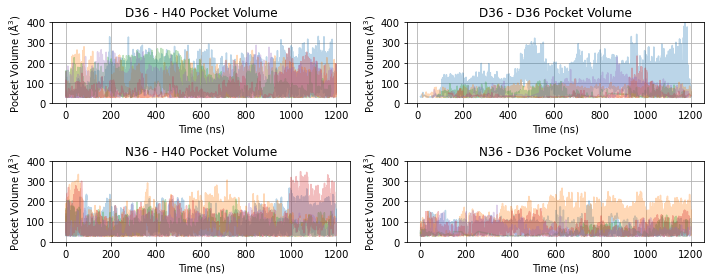

In [ ]:
dir_names = ['D36','N36']
pocket_path = '/localhome/shuchen/projects/ALG8/post_transfer/simulations/stripped/pocket_detection/'
fig, axs = plt.subplots(2,2,figsize=(10,4))
ylim = [0, 400]

# axs[:,0] for D36, axs[:,1] for H40
for i_name, dir_name in enumerate(dir_names):
    for i_traj, traj in enumerate(object_lists[i_name]):
        H40_pocket_vol = np.loadtxt(f'{pocket_path}{dir_name}_{i_traj+1}/{dir_name}_{i_traj+1}_H40_pocket_descriptors.txt', skiprows=1)[:,1]
        D36_pocket_vol = np.loadtxt(f'{pocket_path}{dir_name}_{i_traj+1}/{dir_name}_{i_traj+1}_D36_pocket_descriptors.txt', skiprows=1)[:,1]
        
        x = np.arange(0,len(D36_pocket_vol)*0.2,0.2)[:len(D36_pocket_vol)]
        mask_H40 =  ~(H40_pocket_vol==0) 
        mask_D36 = ~(D36_pocket_vol==0)
        # mask = np.ones(len(x), dtype=bool)
        axs[i_name,0].plot(x[mask_H40], H40_pocket_vol[mask_H40], label=f'Run {i_traj+1}', alpha=0.3)
        axs[i_name,1].plot(x[mask_D36], D36_pocket_vol[mask_D36], label=f'Run {i_traj+1}', alpha=0.3)

    axs[i_name,0].set_title(f'{dir_name} - H40 Pocket Volume')
    axs[i_name,0].set_xlabel('Time (ns)')
    axs[i_name,0].set_ylabel(r'Pocket Volume ($\rm \AA^3$)')
    axs[i_name,0].grid()
    axs[i_name,0].set_ylim(ylim)

    axs[i_name,1].set_title(f'{dir_name} - D36 Pocket Volume')
    axs[i_name,1].set_xlabel('Time (ns)')
    axs[i_name,1].set_ylabel(r'Pocket Volume ($\rm \AA^3$)')
    axs[i_name,1].grid()
    axs[i_name,1].set_ylim(ylim)
plt.tight_layout()
# filename = figdir+'Pocket_volume_D36_H40.png'
# plt.savefig(filename)
        

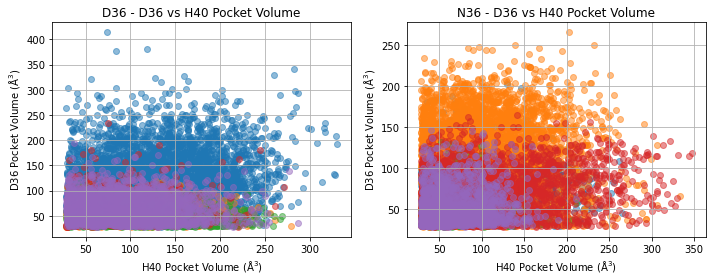

In [ ]:

fig, axs = plt.subplots(1,2,figsize=(10,4))
# axs[:,0] for D36, axs[:,1] for H40
for i_name, dir_name in enumerate(dir_names):
    for i_traj, traj in enumerate(object_lists[i_name]):
        H40_pocket_vol = np.loadtxt(f'{pocket_path}{dir_name}_{i_traj+1}/{dir_name}_{i_traj+1}_H40_pocket_descriptors.txt', skiprows=1)[:,1]
        D36_pocket_vol = np.loadtxt(f'{pocket_path}{dir_name}_{i_traj+1}/{dir_name}_{i_traj+1}_D36_pocket_descriptors.txt', skiprows=1)[:,1]
        mask = ~(H40_pocket_vol==0) &   ~(D36_pocket_vol==0)
        H40_pocket_vol = H40_pocket_vol[mask]
        D36_pocket_vol = D36_pocket_vol[mask]
        x = np.arange(0,len(D36_pocket_vol)*0.2,0.2)[:len(D36_pocket_vol)]
        axs[i_name].scatter(H40_pocket_vol, D36_pocket_vol, label=f'Run {i_traj+1}', alpha=0.5)

    axs[i_name].set_title(f'{dir_name} - D36 vs H40 Pocket Volume')
    axs[i_name].set_xlabel(r'H40 Pocket Volume ($\rm \AA^3$)')
    axs[i_name].set_ylabel(r'D36 Pocket Volume ($\rm \AA^3$)')
    axs[i_name].grid()  
plt.tight_layout()
# filename = figdir+'Pocket_volume_D36_H40.png'
# plt.savefig(filename)
        

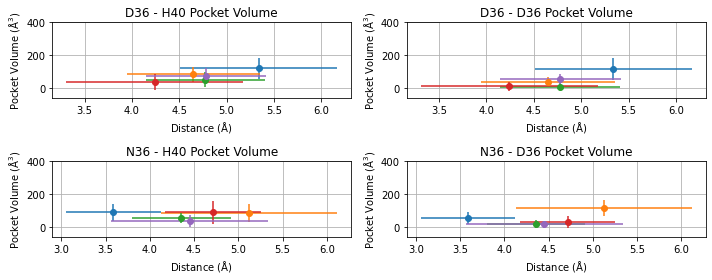

In [ ]:
fig, axs = plt.subplots(2,2,figsize=(10,4))
discard_frames = 2400
ylim = [-60, 400]
object_lists_subset = [object_lists[0], object_lists[3]]
# axs[:,0] for D36, axs[:,1] for H40
r_bins = np.linspace(0,10,40)
vol_bins = np.linspace(0,400,40)
for i_name, dir_name in enumerate(dir_names):
    AS_RMSD_tot_H40 = []
    H40_pocket_vol_tot = []
    AS_RMSD_tot_D36 =[]
    D36_pocket_vol_tot = []
    for i_traj, traj in enumerate(object_lists[i_name]):
        H40_pocket_vol = np.loadtxt(f'{pocket_path}{dir_name}_{i_traj+1}/{dir_name}_{i_traj+1}_H40_pocket_descriptors.txt', skiprows=1)[:,1]
        D36_pocket_vol = np.loadtxt(f'{pocket_path}{dir_name}_{i_traj+1}/{dir_name}_{i_traj+1}_D36_pocket_descriptors.txt', skiprows=1)[:,1]
        AS_RMSD = object_lists_subset[i_name][i_traj].AS_rmsd
        x = np.arange(0,len(D36_pocket_vol)*0.2,0.2)[:len(D36_pocket_vol)]
        mask_H40 =  ~(H40_pocket_vol==0) 
        mask_D36 = ~(D36_pocket_vol==0)
        mask_time = np.arange(len(x)) >= discard_frames
        mask_H40 = mask_time  # & mask_H40 
        mask_D36 = mask_time # & mask_D36
        axs[i_name,0].errorbar(np.average(AS_RMSD[mask_H40]), np.average(H40_pocket_vol[mask_H40]), xerr=np.std(AS_RMSD[mask_H40]), yerr=np.std(H40_pocket_vol[mask_H40]), fmt='o', label=f'Run {i_traj+1}')
        axs[i_name,1].errorbar(np.average(AS_RMSD[mask_D36]), np.average(D36_pocket_vol[mask_D36]), xerr=np.std(AS_RMSD[mask_D36]), yerr=np.std(D36_pocket_vol[mask_D36]), fmt='o', label=f'Run {i_traj+1}')
    axs[i_name,0].set_title(f'{dir_name} - H40 Pocket Volume')
    axs[i_name,0].set_xlabel(r'Distance ($\rm \AA$)')
    axs[i_name,0].set_ylabel(r'Pocket Volume ($\rm \AA^3$)')
    axs[i_name,0].grid()
    axs[i_name,0].set_ylim(ylim)

    axs[i_name,1].set_title(f'{dir_name} - D36 Pocket Volume')
    axs[i_name,1].set_xlabel(r'Distance ($\rm \AA$)')
    axs[i_name,1].set_ylabel(r'Pocket Volume ($\rm \AA^3$)')
    axs[i_name,1].grid()
    axs[i_name,1].set_ylim(ylim)
plt.tight_layout()
# filename = figdir+'Pocket_volume_D36_H40.png'
# plt.savefig(filename)
        

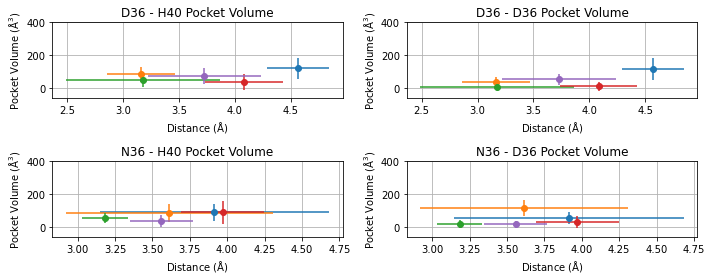

In [ ]:
fig, axs = plt.subplots(2,2,figsize=(10,4))
discard_frames = 2400
ylim = [-60, 400]
object_lists_subset = [object_lists[0], object_lists[3]]
# axs[:,0] for D36, axs[:,1] for H40
r_bins = np.linspace(0,10,40)
vol_bins = np.linspace(0,400,40)
for i_name, dir_name in enumerate(dir_names):
    DS_RMSD_tot_H40 = []
    H40_pocket_vol_tot = []
    DS_RMSD_tot_D36 =[]
    D36_pocket_vol_tot = []
    for i_traj, traj in enumerate(object_lists[i_name]):
        H40_pocket_vol = np.loadtxt(f'{pocket_path}{dir_name}_{i_traj+1}/{dir_name}_{i_traj+1}_H40_pocket_descriptors.txt', skiprows=1)[:,1]
        D36_pocket_vol = np.loadtxt(f'{pocket_path}{dir_name}_{i_traj+1}/{dir_name}_{i_traj+1}_D36_pocket_descriptors.txt', skiprows=1)[:,1]
        DS_RMSD = object_lists_subset[i_name][i_traj].DS_rmsd
        x = np.arange(0,len(D36_pocket_vol)*0.2,0.2)[:len(D36_pocket_vol)]
        mask_H40 =  ~(H40_pocket_vol==0) 
        mask_D36 = ~(D36_pocket_vol==0)
        mask_time = np.arange(len(x)) >= discard_frames
        mask_H40 = mask_time  # & mask_H40 
        mask_D36 = mask_time # & mask_D36
        axs[i_name,0].errorbar(np.average(DS_RMSD[mask_H40]), np.average(H40_pocket_vol[mask_H40]), xerr=np.std(DS_RMSD[mask_H40]), yerr=np.std(H40_pocket_vol[mask_H40]), fmt='o', label=f'Run {i_traj+1}')
        axs[i_name,1].errorbar(np.average(DS_RMSD[mask_D36]), np.average(D36_pocket_vol[mask_D36]), xerr=np.std(DS_RMSD[mask_D36]), yerr=np.std(D36_pocket_vol[mask_D36]), fmt='o', label=f'Run {i_traj+1}')
    axs[i_name,0].set_title(f'{dir_name} - H40 Pocket Volume')
    axs[i_name,0].set_xlabel(r'Distance ($\rm \AA$)')
    axs[i_name,0].set_ylabel(r'Pocket Volume ($\rm \AA^3$)')
    axs[i_name,0].grid()
    axs[i_name,0].set_ylim(ylim)

    axs[i_name,1].set_title(f'{dir_name} - D36 Pocket Volume')
    axs[i_name,1].set_xlabel(r'Distance ($\rm \AA$)')
    axs[i_name,1].set_ylabel(r'Pocket Volume ($\rm \AA^3$)')
    axs[i_name,1].grid()
    axs[i_name,1].set_ylim(ylim)
plt.tight_layout()
# filename = figdir+'Pocket_volume_D36_H40.png'
# plt.savefig(filename)
        

# statistics

In [ ]:
from scipy import stats
from itertools import combinations
import matplotlib.patches as mpatches

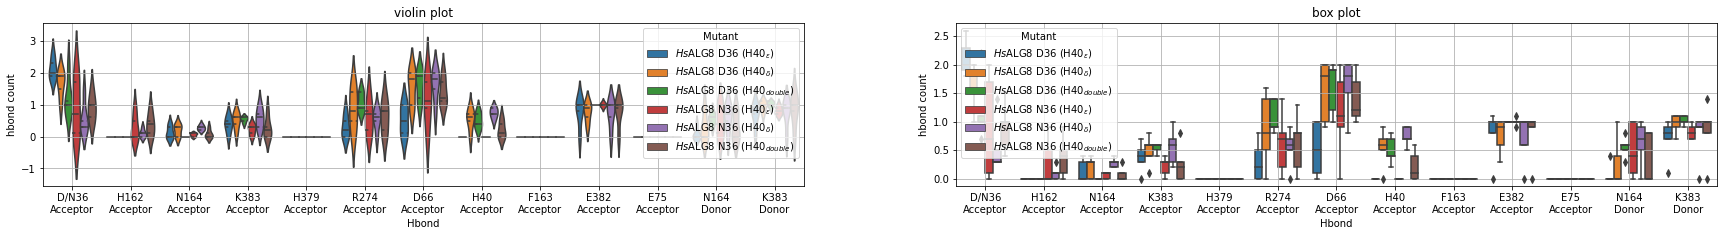

In [ ]:
# AS-D82 distance
fig, axs = plt.subplots(1,2,figsize=(30,3))
sliding_window = 10
discard_ratio = 0.2
df = pd.DataFrame()
for i_object_list, object_list in enumerate(object_lists):
    for i_obj, obj in enumerate(object_list):
        get_frame_index = int(len(obj.pro_rmsd)*discard_ratio)
        data = [sliding_average(obj.protein_substrates_bonds[0,i_rec][get_frame_index:],window_size=sliding_window) for i_rec in range(len(obj.rec_name))]
        data = data + [sliding_average(obj.protein_substrates_bonds[1,2][get_frame_index:],window_size=sliding_window)]+ [sliding_average(obj.protein_substrates_bonds[1,3][get_frame_index:],window_size=sliding_window)]
        data_names = [f'{recname}\nAcceptor' for recname in obj.rec_name]
        data_names = data_names + [f'{obj.rec_name[2]}\nDonor'] + [f'{obj.rec_name[3]}\nDonor']
        data_names[0] = 'D/N36\nAcceptor'
        for i_data, data_name in enumerate(data_names):
            df_ = pd.DataFrame(data[i_data]).T
            df_['Hbond'] = data_name
            df_['Run'] = f'{i_obj+1}'
            df_['Mutant'] = object_names[i_object_list]
            df = pd.concat([df, df_], ignore_index=True)
        # df_.columns = data_name
        # df_ = pd.DataFrame(data).T
        # df_.columns = data_name
        
    
sns.violinplot(data=df, x='Hbond', y=0, hue='Mutant', inner='quartile', scale='width', ax=axs[0])
sns.boxplot(data=df, x='Hbond', y=0, hue='Mutant', ax=axs[1])
titles = ['violin plot', 'box plot']
# calculate significance

for i_ax, ax in enumerate(axs):
    ax.set_title(titles[i_ax])
    ax.set_ylabel(r'hbond count')
    ax.grid()
   
filename = figdir+'/hbond_violin_box.png'
plt.savefig(filename, dpi=300)

### Statistics

In [ ]:
# H-bond Correlation Matrix Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

In [ ]:
# AS-D82 distance
sliding_window = 10
discard_ratio = 0.2
df = pd.DataFrame()
correlation_data = {}

for i_object_list, object_list in enumerate(object_lists):
    mutant_name = object_names[i_object_list]
    correlation_data[mutant_name] = {}

    for i_obj, obj in enumerate(object_list):
        get_frame_index = int(len(obj.pro_rmsd)*discard_ratio)
        run_key = f'Run_{i_obj+1}'
        hbond_data = {}
        
        data = [sliding_average(obj.protein_substrates_bonds[0,i_rec][get_frame_index:],window_size=sliding_window) for i_rec in range(len(obj.rec_name)-1)]
        data = data + [sliding_average(obj.protein_substrates_bonds[1,2][get_frame_index:],window_size=sliding_window)] +  [sliding_average(obj.protein_substrates_bonds[1,3][get_frame_index:],window_size=sliding_window)]
        data_names = [f'{recname}\nAcceptor' for recname in obj.rec_name[:-1]]
        data_names = data_names + [f'{obj.rec_name[2]}\nDonor',f'{obj.rec_name[3]}\nDonor' ]
        data_names[0] = 'D/N36\nAcceptor'
        
        for i_data, data_name in enumerate(data_names):
            df_ = pd.DataFrame(data[i_data]).T
            df_['Hbond'] = data_name
            df_['Run'] = f'{i_obj+1}'
            df_['Mutant'] = object_names[i_object_list]
            df = pd.concat([df, df_], ignore_index=True)
            hbond_data[data_name] = data[i_data]

        for i_rec1, recname1 in enumerate(obj.rec_name):
            for i_rec2 in range(i_rec1+1, len(obj.rec_name)):
                if i_rec1 == 1 and i_rec2 == 2:
                    continue # this pair is not considered
                get_frame_index = int(len(obj.pro_rmsd)*discard_ratio)
                data = sliding_average(obj.protein_inter_hbonds[i_rec1,i_rec2][get_frame_index:],window_size=sliding_window)
                if i_rec1 ==0 :
                    data_name = f'D/N36\n{obj.rec_name[i_rec2]}'
                else:
                    data_name = f'{recname1}\n{obj.rec_name[i_rec2]}'
                df_ = pd.DataFrame(data).T
                df_['Hbond'] = data_name
                df_['Run'] = f'{i_obj+1}'
                df_['Mutant'] = object_names[i_object_list]
                df = pd.concat([df, df_], ignore_index=True)
                hbond_data[data_name] = data
                
        correlation_data[mutant_name][run_key] = pd.DataFrame(hbond_data)

In [ ]:
correlation_data = {}

for i_object_list, object_list in enumerate(object_lists):
    mutant_name = object_names[i_object_list]
    correlation_data[mutant_name] = {}
    
    for i_obj, obj in enumerate(object_list):
        get_frame_index = int(len(obj.pro_rmsd)*discard_ratio)
        
        # Initialize dictionary for this run
        run_key = f'Run_{i_obj+1}'
        hbond_data = {}
        
        # 1. Process protein-substrate bonds
        data = [sliding_average(obj.protein_substrates_bonds[0,i_rec][get_frame_index:],window_size=sliding_window) for i_rec in range(len(obj.rec_name)-1)]
        data = data + [sliding_average(obj.protein_substrates_bonds[1,-2][get_frame_index:],window_size=sliding_window)] +  [sliding_average(obj.protein_substrates_bonds[1,-1][get_frame_index:],window_size=sliding_window)]
        data_names = [f'{recname}\nAcceptor' for recname in obj.rec_name[:-1]]
        data_names = data_names + [f'{obj.rec_name[-2]}\nDonor',f'{obj.rec_name[-1]}\nDonor' ]
        data_names[0] = 'D/N36\nAcceptor'
        
        # Store protein-substrate bond data
        for i_data, data_name in enumerate(data_names):
            hbond_data[data_name] = data[i_data]
        
        # 2. Process protein inter-H-bonds
        for i_rec1, recname1 in enumerate(obj.rec_name[:-1]):
            for i_rec2 in range(i_rec1+1, len(obj.rec_name)):
                
                data = sliding_average(obj.protein_inter_hbonds[i_rec1,i_rec2][get_frame_index:],window_size=sliding_window)
                if i_rec1 == 0:
                    data_name = f'D/N36\n{obj.rec_name[i_rec2]}'
                else:
                    data_name = f'{recname1}\n{obj.rec_name[i_rec2]}'
                hbond_data[data_name] = data
                
        # Convert to DataFrame and store
        correlation_data[mutant_name][run_key] = pd.DataFrame(hbond_data)


In [ ]:
# to do 
# remove the entries with low data on both mutants


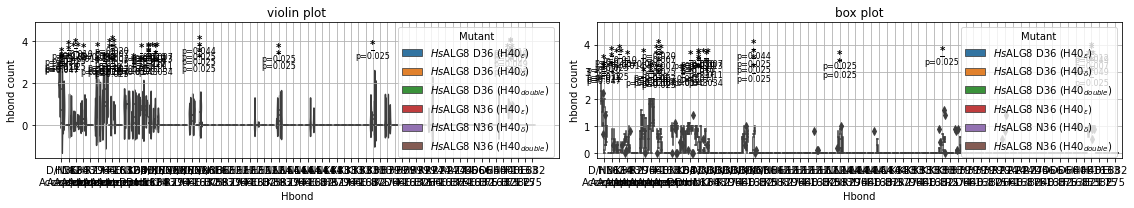

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(16,3))
# Function to get significance stars
def get_significance_stars(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

# Function to add significance annotations
def add_significance_annotations(ax, df, y_col=0):
    # Get unique hbond types and mutants
    hbond_types = df['Hbond'].unique()
    mutants = df['Mutant'].unique()
    
    # If only one mutant, no comparisons to make
    if len(mutants) < 2:
        return
    
    # Calculate maximum y value for positioning annotations
    max_y = df[y_col].max()
    y_range = df[y_col].max() - df[y_col].min()
    
    # For each hbond type, compare mutants pairwise
    for i, hbond_type in enumerate(hbond_types):
        hbond_data = df[df['Hbond'] == hbond_type]
        
        # Get data for each mutant
        mutant_groups = []
        for mutant in mutants:
            mutant_data = hbond_data[hbond_data['Mutant'] == mutant][y_col].values
            if len(mutant_data) > 0:
                mutant_groups.append((mutant, mutant_data))
        
        if len(mutant_groups) < 2:
            continue
            
        # Perform pairwise comparisons
        y_offset = max_y + 0.05 * y_range  # Starting height for annotations
        comparison_height = 0.03 * y_range  # Height increment between comparisons
        
        for j, (mut1, mut2) in enumerate(combinations(mutant_groups, 2)):
            mutant1, data1 = mut1
            mutant2, data2 = mut2
            
            # Perform Mann-Whitney U test (non-parametric)
            # You can also use stats.ttest_ind for t-test if data is normally distributed
            try:
                statistic, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                stars = get_significance_stars(p_value)
                
                if stars != 'ns':  # Only show significant results
                    # Calculate x positions for the comparison
                    x_pos = i
                    
                    # Add horizontal line
                    y_pos = y_offset + j * comparison_height
                    ax.plot([x_pos - 0.2, x_pos + 0.2], [y_pos, y_pos], 'k-', linewidth=1)
                    
                    # Add significance stars
                    ax.text(x_pos, y_pos + 0.01 * y_range, stars, 
                           ha='center', va='bottom', fontsize=10, fontweight='bold')
                    
                    # Add p-value below stars (optional)
                    if p_value < 0.001:
                        p_text = f'p<0.001'
                    else:
                        p_text = f'p={p_value:.3f}'
                    ax.text(x_pos, y_pos - 0.02 * y_range, p_text, 
                           ha='center', va='top', fontsize=8)
                           
            except ValueError:
                # Skip if insufficient data for comparison
                continue

# Create plots
sns.violinplot(data=df, x='Hbond', y=0, hue='Mutant', inner='quartile', scale='width', ax=axs[0])
sns.boxplot(data=df, x='Hbond', y=0, hue='Mutant', ax=axs[1])

titles = ['violin plot', 'box plot']

# Add significance annotations and formatting
for i_ax, ax in enumerate(axs):
    ax.set_title(titles[i_ax])
    ax.set_ylabel(r'hbond count')
    ax.grid()
    
    # Add significance annotations
    add_significance_annotations(ax, df, y_col=0)
    
    # Adjust y-axis to accommodate significance annotations
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.2)  # Add 20% space at top

# Add legend for significance levels
significance_legend = [
    mpatches.Patch(color='none', label='*** p < 0.001'),
    mpatches.Patch(color='none', label='** p < 0.01'),
    mpatches.Patch(color='none', label='* p < 0.05'),
]

# Add significance legend to the right side of the figure
# fig.legend(handles=significance_legend, loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.tight_layout()
filename = figdir+'/hbond_violin_box.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')  # bbox_inches='tight' to include legend

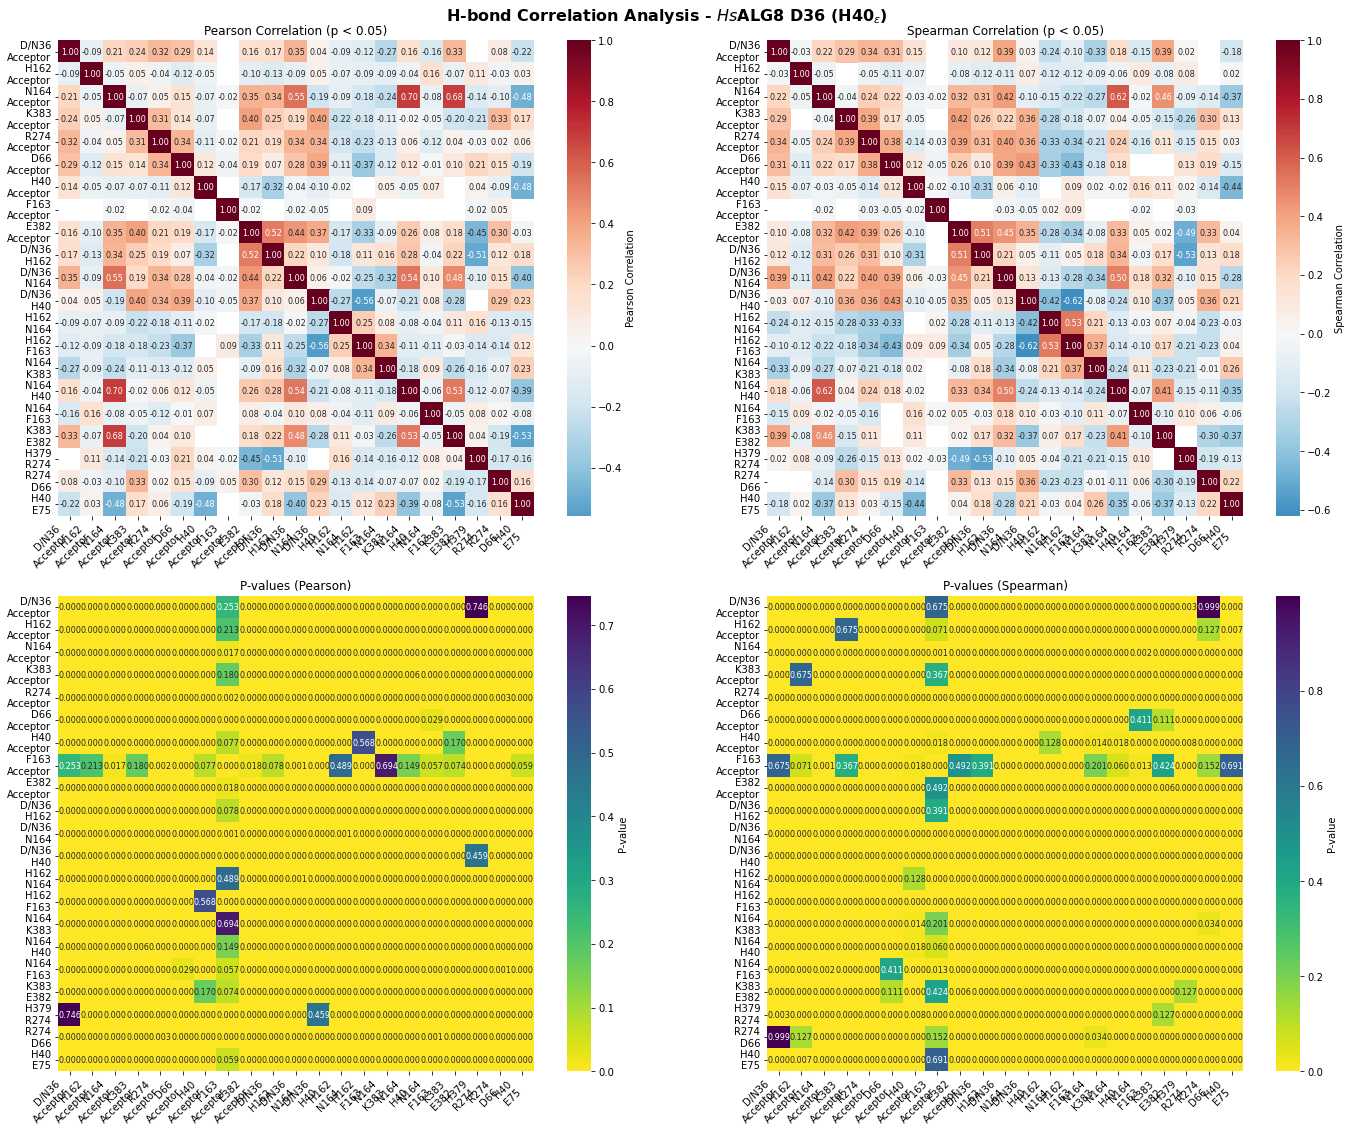


H-bond categories for $Hs$ALG8 D36 (H40$_{\epsilon}$):
  Protein-Substrate (Acceptor): 9 bonds
    - D/N36
Acceptor
    - H162
Acceptor
    - N164
Acceptor
    - K383
Acceptor
    - R274
Acceptor
    - D66
Acceptor
    - H40
Acceptor
    - F163
Acceptor
    - E382
Acceptor
  Protein-Protein: 12 bonds
    - D/N36
H162
    - D/N36
N164
    - D/N36
H40
    - H162
N164
    - H162
F163
    - N164
K383
    - N164
H40
    - N164
F163
    - K383
E382
    - H379
R274
    - R274
D66
    - H40
E75


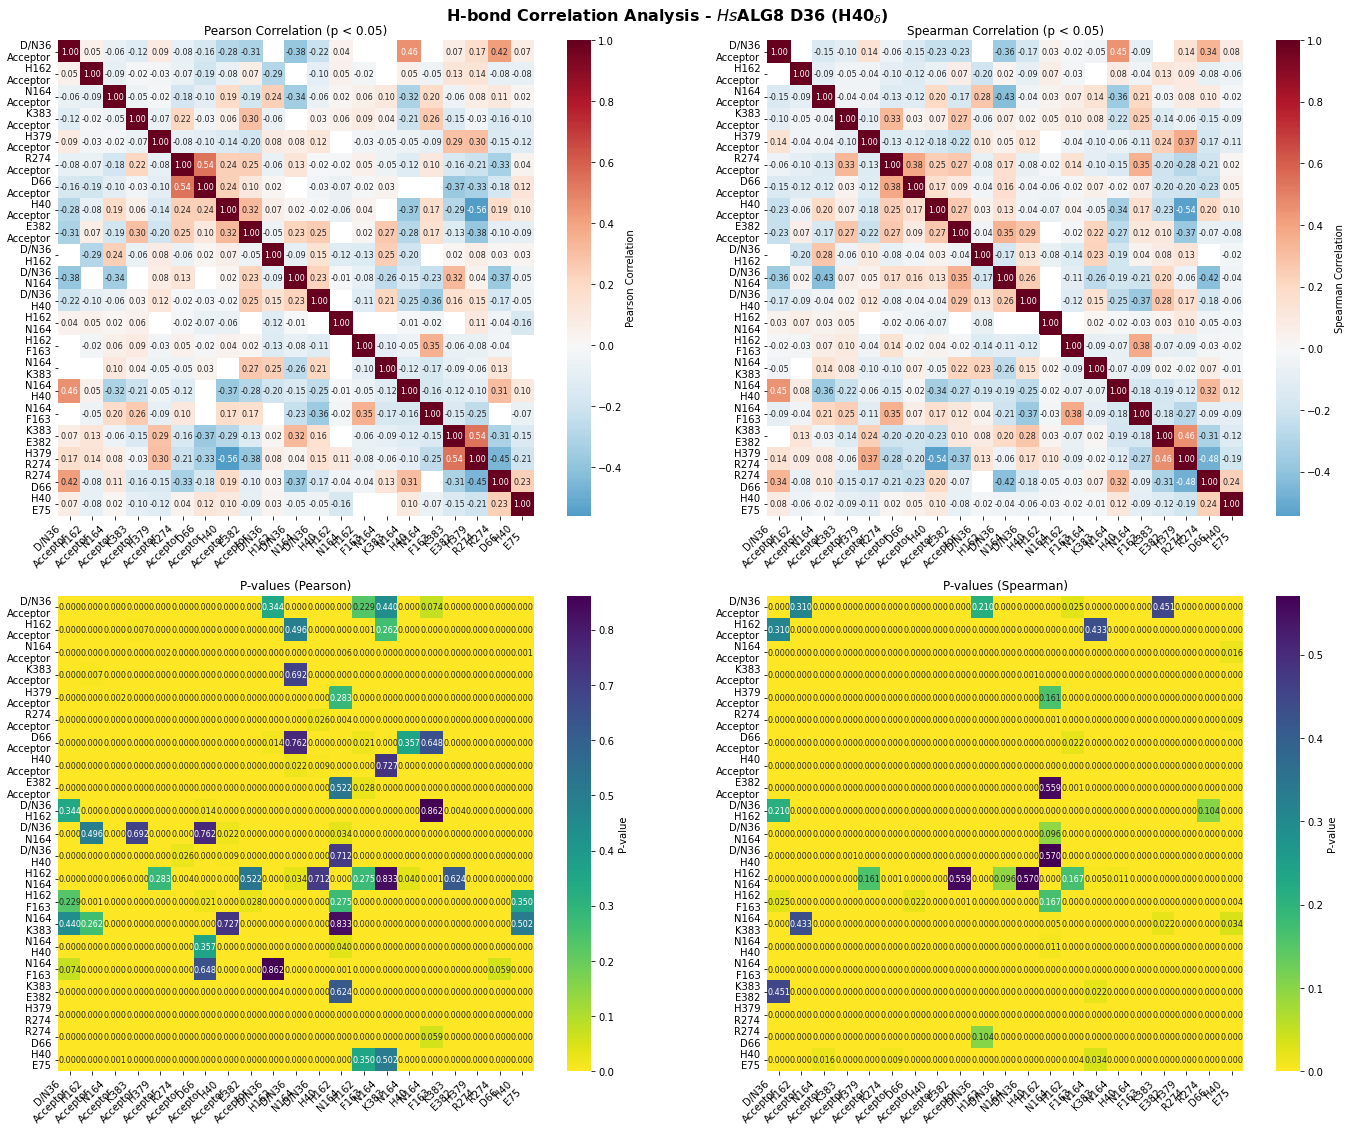


H-bond categories for $Hs$ALG8 D36 (H40$_{\delta}$):
  Protein-Substrate (Acceptor): 9 bonds
    - D/N36
Acceptor
    - H162
Acceptor
    - N164
Acceptor
    - K383
Acceptor
    - H379
Acceptor
    - R274
Acceptor
    - D66
Acceptor
    - H40
Acceptor
    - E382
Acceptor
  Protein-Protein: 12 bonds
    - D/N36
H162
    - D/N36
N164
    - D/N36
H40
    - H162
N164
    - H162
F163
    - N164
K383
    - N164
H40
    - N164
F163
    - K383
E382
    - H379
R274
    - R274
D66
    - H40
E75


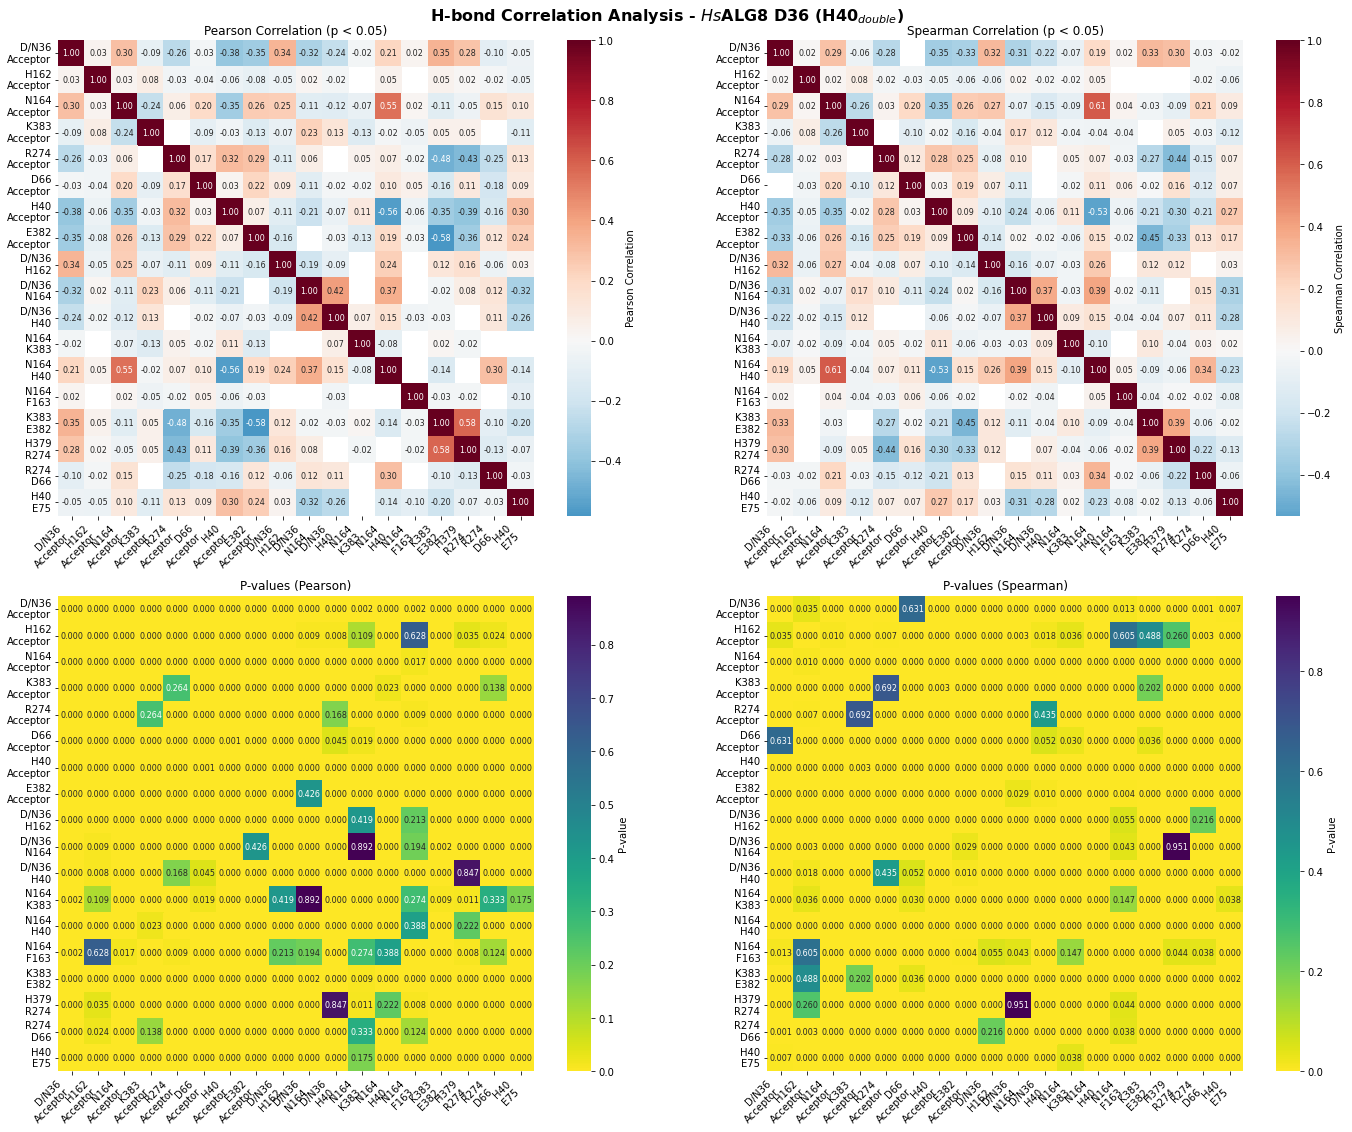


H-bond categories for $Hs$ALG8 D36 (H40$_{double}$):
  Protein-Substrate (Acceptor): 8 bonds
    - D/N36
Acceptor
    - H162
Acceptor
    - N164
Acceptor
    - K383
Acceptor
    - R274
Acceptor
    - D66
Acceptor
    - H40
Acceptor
    - E382
Acceptor
  Protein-Protein: 10 bonds
    - D/N36
H162
    - D/N36
N164
    - D/N36
H40
    - N164
K383
    - N164
H40
    - N164
F163
    - K383
E382
    - H379
R274
    - R274
D66
    - H40
E75


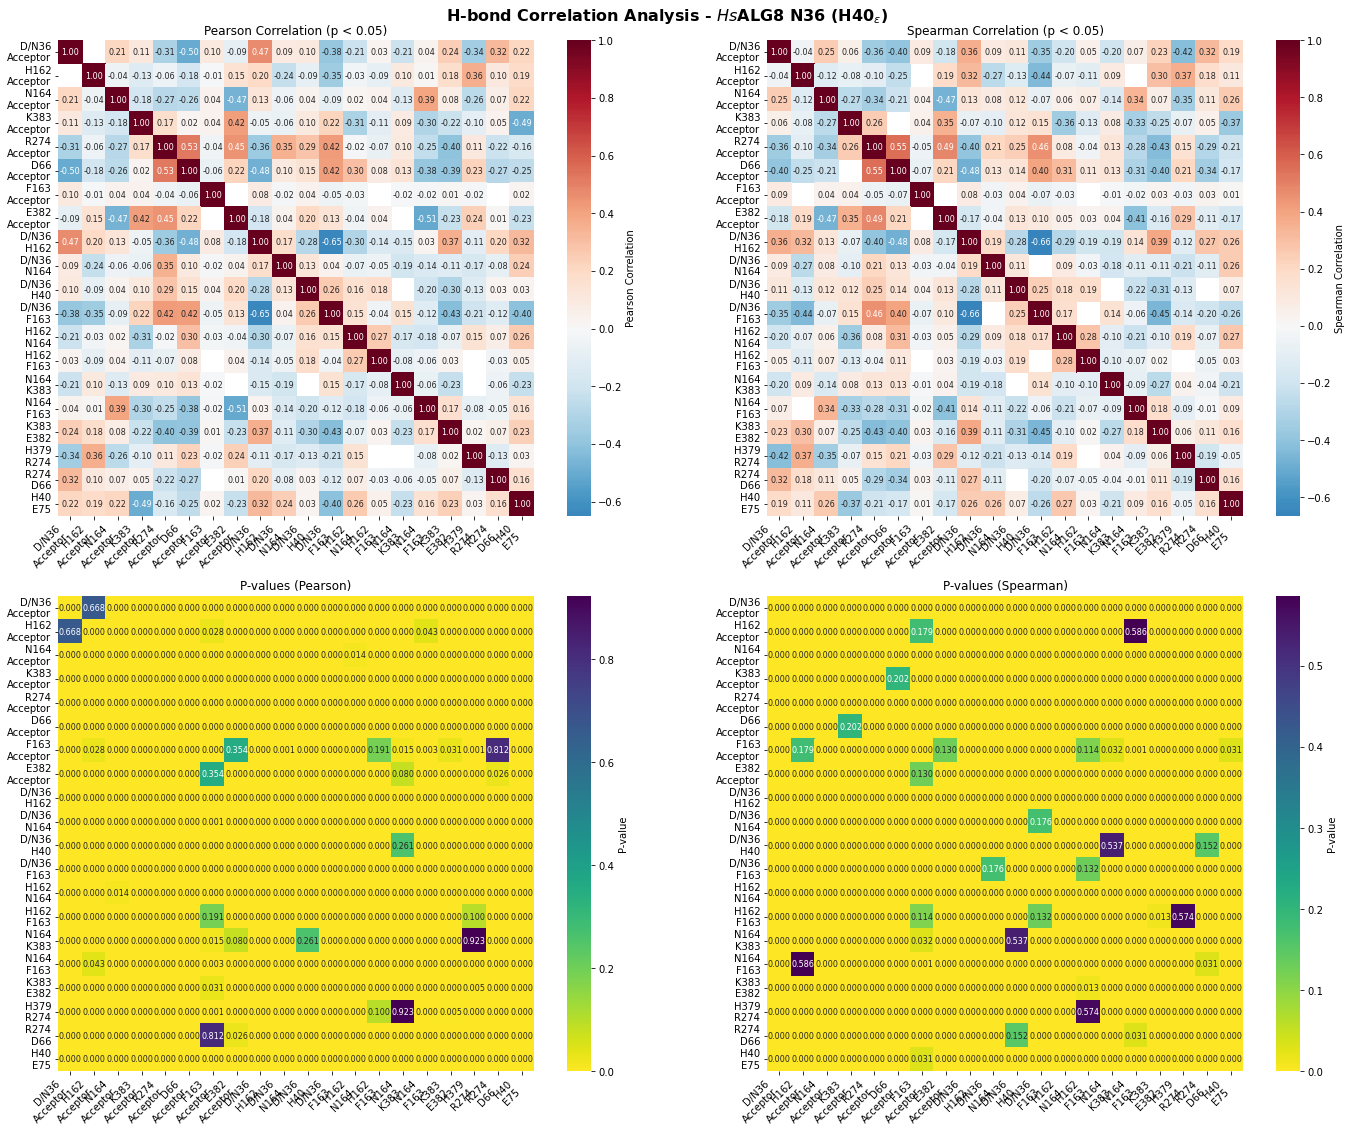


H-bond categories for $Hs$ALG8 N36 (H40$_{\epsilon}$):
  Protein-Substrate (Acceptor): 8 bonds
    - D/N36
Acceptor
    - H162
Acceptor
    - N164
Acceptor
    - K383
Acceptor
    - R274
Acceptor
    - D66
Acceptor
    - F163
Acceptor
    - E382
Acceptor
  Protein-Protein: 12 bonds
    - D/N36
H162
    - D/N36
N164
    - D/N36
H40
    - D/N36
F163
    - H162
N164
    - H162
F163
    - N164
K383
    - N164
F163
    - K383
E382
    - H379
R274
    - R274
D66
    - H40
E75


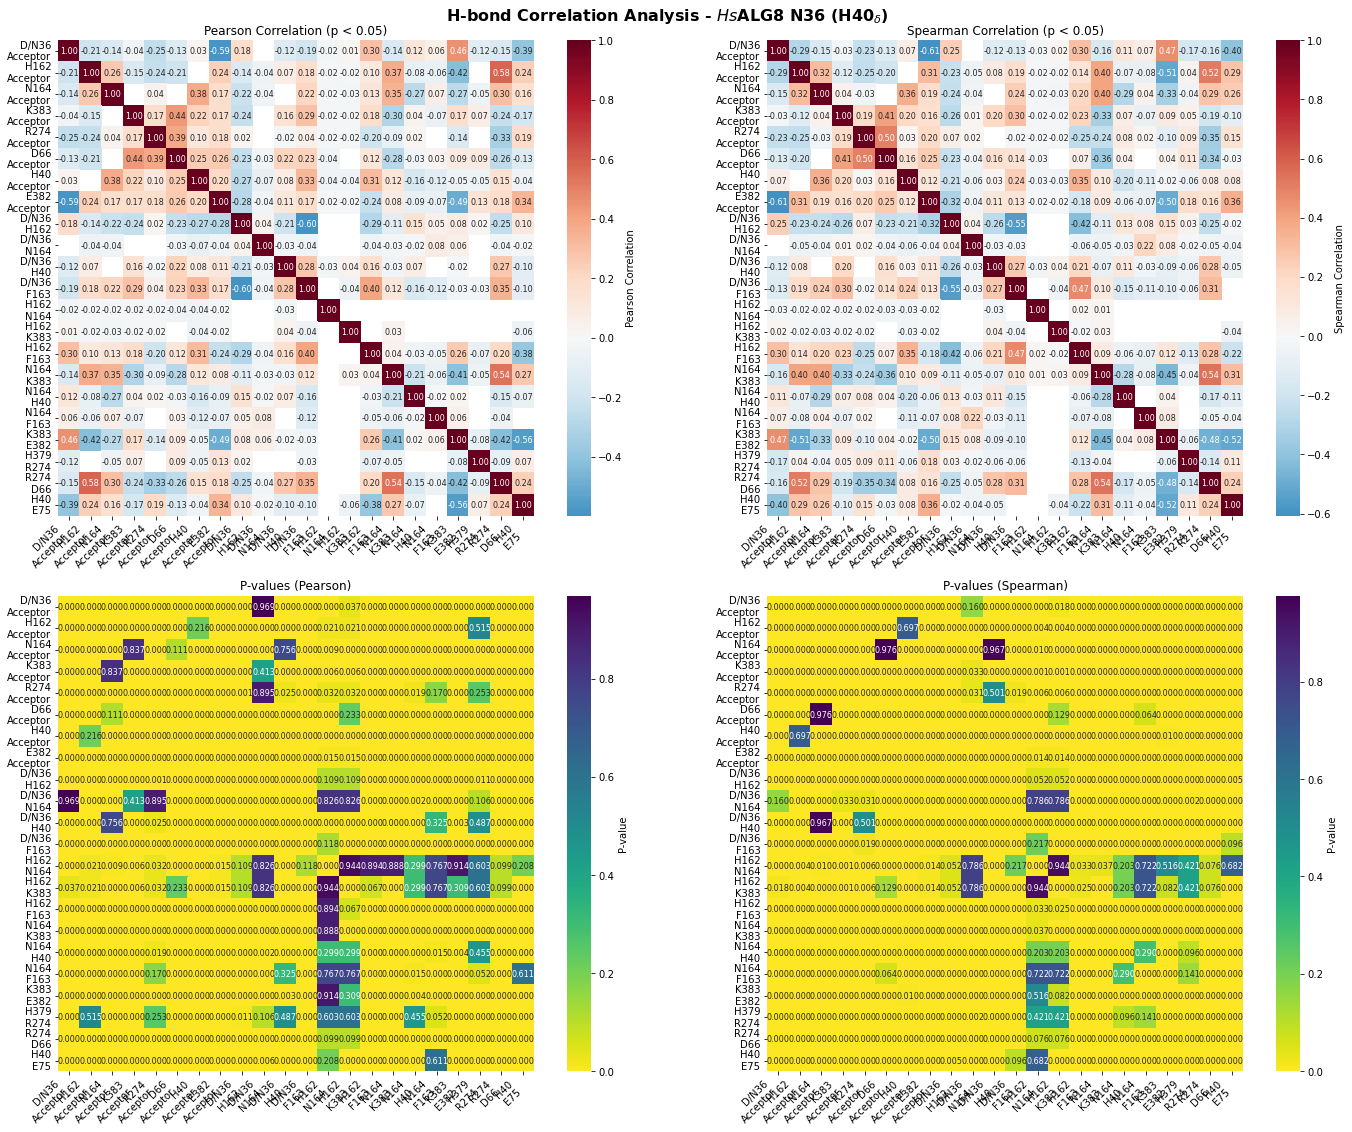


H-bond categories for $Hs$ALG8 N36 (H40$_{\delta}$):
  Protein-Substrate (Acceptor): 8 bonds
    - D/N36
Acceptor
    - H162
Acceptor
    - N164
Acceptor
    - K383
Acceptor
    - R274
Acceptor
    - D66
Acceptor
    - H40
Acceptor
    - E382
Acceptor
  Protein-Protein: 14 bonds
    - D/N36
H162
    - D/N36
N164
    - D/N36
H40
    - D/N36
F163
    - H162
N164
    - H162
K383
    - H162
F163
    - N164
K383
    - N164
H40
    - N164
F163
    - K383
E382
    - H379
R274
    - R274
D66
    - H40
E75


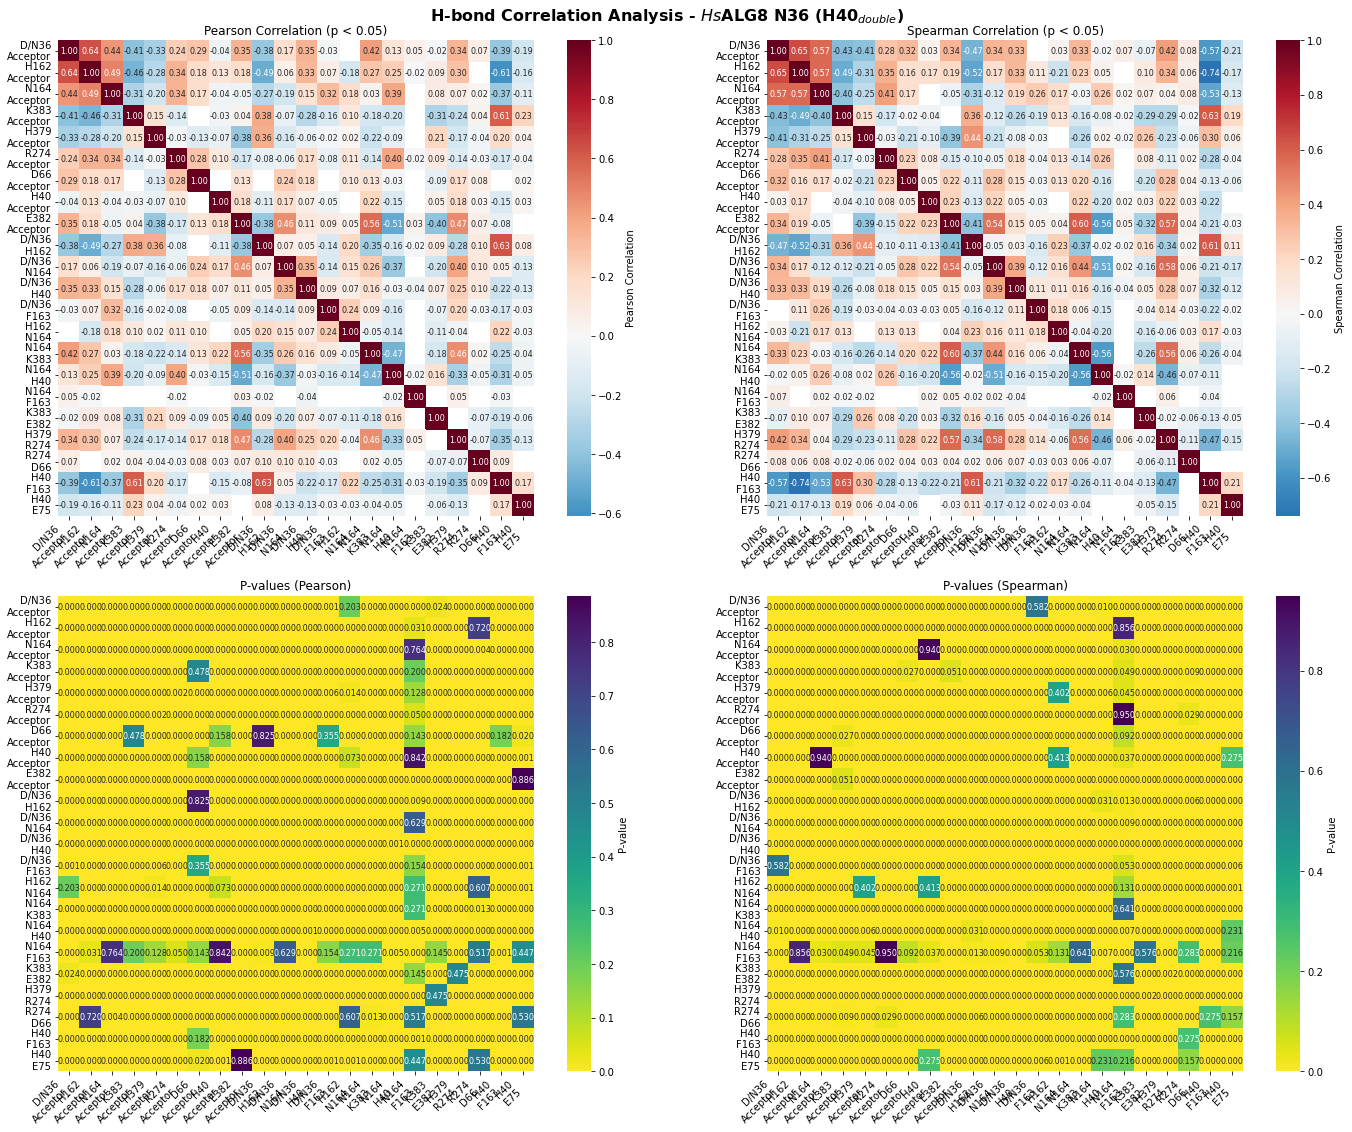


H-bond categories for $Hs$ALG8 N36 (H40$_{double}$):
  Protein-Substrate (Acceptor): 9 bonds
    - D/N36
Acceptor
    - H162
Acceptor
    - N164
Acceptor
    - K383
Acceptor
    - H379
Acceptor
    - R274
Acceptor
    - D66
Acceptor
    - H40
Acceptor
    - E382
Acceptor
  Protein-Protein: 13 bonds
    - D/N36
H162
    - D/N36
N164
    - D/N36
H40
    - D/N36
F163
    - H162
N164
    - N164
K383
    - N164
H40
    - N164
F163
    - K383
E382
    - H379
R274
    - R274
D66
    - H40
F163
    - H40
E75

Creating combined correlation analysis...


/localhome/shuchen/.conda/envs/shu_pytraj/lib/python3.6/site-packages/seaborn/matrix.py:1214: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 1152x1008 with 0 Axes>

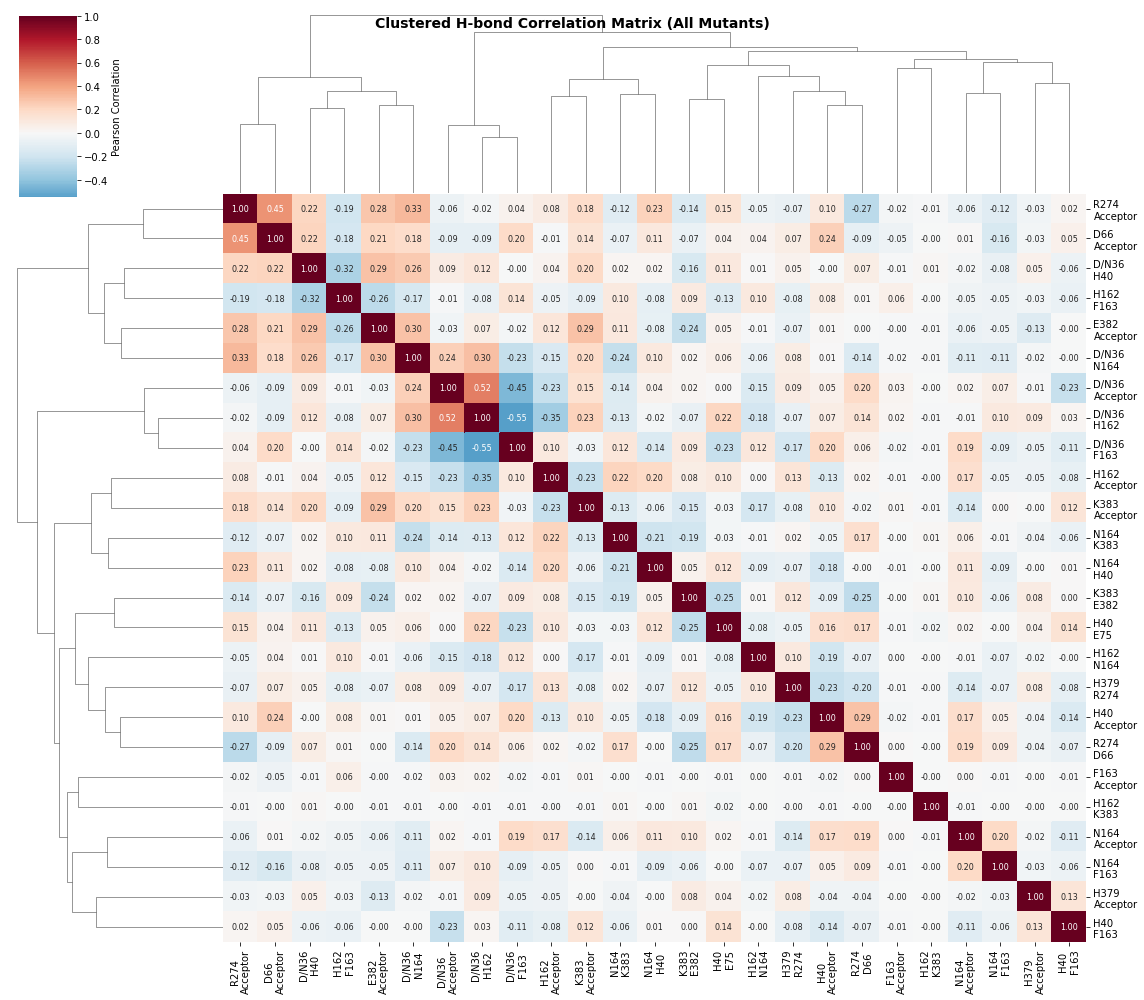


Correlation Summary Statistics:

$Hs$ALG8 D36 (H40$_{\epsilon}$):
  Number of H-bond pairs: 21
  Number of correlations: 210
  Mean correlation: 0.018
  Std correlation: 0.217
  Max correlation: 0.697
  Min correlation: -0.557
  Top 3 strongest correlations:
    N164
Acceptor ↔ N164
H40: 0.697
    N164
Acceptor ↔ K383
E382: 0.684
    D/N36
H40 ↔ H162
F163: -0.557

$Hs$ALG8 D36 (H40$_{\delta}$):
  Number of H-bond pairs: 21
  Number of correlations: 210
  Mean correlation: -0.019
  Std correlation: 0.176
  Max correlation: 0.541
  Min correlation: -0.558
  Top 3 strongest correlations:
    H40
Acceptor ↔ H379
R274: -0.558
    R274
Acceptor ↔ D66
Acceptor: 0.541
    K383
E382 ↔ H379
R274: 0.538

$Hs$ALG8 D36 (H40$_{double}$):
  Number of H-bond pairs: 18
  Number of correlations: 153
  Mean correlation: -0.010
  Std correlation: 0.188
  Max correlation: 0.585
  Min correlation: -0.582
  Top 3 strongest correlations:
    K383
E382 ↔ H379
R274: 0.585
    E382
Acceptor ↔ K383
E382: -0.582


In [ ]:
# H-bond Correlation Matrix Analysis - Updated for Complex Data Structure

# Function to calculate correlation matrix
def calculate_correlation_matrix(data_df, method='pearson'):
    """
    Calculate correlation matrix using specified method
    
    Parameters:
    data_df: DataFrame with H-bond data
    method: 'pearson' or 'spearman'
    """
    if method == 'pearson':
        corr_matrix = data_df.corr(method='pearson')
    elif method == 'spearman':
        corr_matrix = data_df.corr(method='spearman')
    
    return corr_matrix

# Function to get correlation with p-values
def get_correlation_with_pvalues(data_df, method='pearson'):
    """
    Calculate correlation matrix with p-values
    """
    columns = data_df.columns
    n_vars = len(columns)
    
    corr_matrix = np.zeros((n_vars, n_vars))
    p_matrix = np.zeros((n_vars, n_vars))
    
    for i in range(n_vars):
        for j in range(n_vars):
            if i == j:
                corr_matrix[i, j] = 1.0
                p_matrix[i, j] = 0.0
            else:
                try:
                    if method == 'pearson':
                        corr, p_val = pearsonr(data_df.iloc[:, i], data_df.iloc[:, j])
                    elif method == 'spearman':
                        corr, p_val = spearmanr(data_df.iloc[:, i], data_df.iloc[:, j])
                    
                    corr_matrix[i, j] = corr
                    p_matrix[i, j] = p_val
                except:
                    # Handle cases with constant values or other issues
                    corr_matrix[i, j] = 0.0
                    p_matrix[i, j] = 1.0
    
    corr_df = pd.DataFrame(corr_matrix, index=columns, columns=columns)
    p_df = pd.DataFrame(p_matrix, index=columns, columns=columns)
    
    return corr_df, p_df

# Function to categorize H-bond types
def categorize_hbond_types(hbond_names):
    """
    Categorize H-bonds into different types for better visualization
    """
    categories = {
        'Protein-Substrate (Acceptor)': [],
        'Protein-Substrate (Donor)': [],
        'Protein-Protein': []
    }
    
    for name in hbond_names:
        if 'Acceptor' in name:
            categories['Protein-Substrate (Acceptor)'].append(name)
        elif 'Donor' in name:
            categories['Protein-Substrate (Donor)'].append(name)
        else:
            categories['Protein-Protein'].append(name)
    
    return categories

# Create correlation plots for each mutant
for mutant_name in correlation_data.keys():
    mutant_data = correlation_data[mutant_name]
    
    # Combine all runs for this mutant
    combined_data = pd.concat([mutant_data[run] for run in mutant_data.keys()], ignore_index=True)
    
    # Remove columns with all zeros or NaN (if any)
    combined_data = combined_data.loc[:, (combined_data != 0).any(axis=0)]
    combined_data = combined_data.dropna(axis=1)
    
    if combined_data.empty or combined_data.shape[1] < 2:
        print(f"Insufficient data for correlation analysis in {mutant_name}")
        continue
    
    # Calculate correlations
    corr_pearson, p_pearson = get_correlation_with_pvalues(combined_data, method='pearson')
    corr_spearman, p_spearman = get_correlation_with_pvalues(combined_data, method='spearman')
    
    # Categorize H-bond types
    categories = categorize_hbond_types(combined_data.columns)
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle(f'H-bond Correlation Analysis - {mutant_name}', fontsize=16, fontweight='bold')
    
    # Pearson correlation heatmap
    mask_pearson = p_pearson > 0.05  # Mask non-significant correlations
    im1 = sns.heatmap(corr_pearson, annot=True, cmap='RdBu_r', center=0, 
                      square=True, fmt='.2f', cbar_kws={'label': 'Pearson Correlation'},
                      mask=mask_pearson, ax=axes[0,0], annot_kws={'size': 8})
    axes[0,0].set_title('Pearson Correlation (p < 0.05)')
    axes[0,0].set_xlabel('')
    
    # Spearman correlation heatmap
    mask_spearman = p_spearman > 0.05  # Mask non-significant correlations
    im2 = sns.heatmap(corr_spearman, annot=True, cmap='RdBu_r', center=0, 
                      square=True, fmt='.2f', cbar_kws={'label': 'Spearman Correlation'},
                      mask=mask_spearman, ax=axes[0,1], annot_kws={'size': 8})
    axes[0,1].set_title('Spearman Correlation (p < 0.05)')
    axes[0,1].set_xlabel('')
    
    # P-value heatmap for Pearson
    im3 = sns.heatmap(p_pearson, annot=True, cmap='viridis_r', 
                      square=True, fmt='.3f', cbar_kws={'label': 'P-value'},
                      ax=axes[1,0], annot_kws={'size': 8})
    axes[1,0].set_title('P-values (Pearson)')
    
    # P-value heatmap for Spearman
    im4 = sns.heatmap(p_spearman, annot=True, cmap='viridis_r', 
                      square=True, fmt='.3f', cbar_kws={'label': 'P-value'},
                      ax=axes[1,1], annot_kws={'size': 8})
    axes[1,1].set_title('P-values (Spearman)')
    
    # Rotate x-axis labels for better readability
    for ax in axes.flat:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    
    # Save figure
    filename = f'{figdir}/hbond_correlation_matrix_{mutant_name}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print H-bond categories for this mutant
    print(f"\nH-bond categories for {mutant_name}:")
    for category, bonds in categories.items():
        if bonds:
            print(f"  {category}: {len(bonds)} bonds")
            for bond in bonds:
                print(f"    - {bond}")

# Create a combined correlation matrix comparing all mutants
print("\nCreating combined correlation analysis...")

# Combine all data with mutant labels
all_data = []
for mutant_name in correlation_data.keys():
    mutant_data = correlation_data[mutant_name]
    combined_mutant_data = pd.concat([mutant_data[run] for run in mutant_data.keys()], ignore_index=True)
    combined_mutant_data['Mutant'] = mutant_name
    all_data.append(combined_mutant_data)

if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Calculate average correlations across all mutants
    hbond_columns = [col for col in combined_df.columns if col != 'Mutant']
    
    # Remove columns with all zeros or constant values
    hbond_data = combined_df[hbond_columns]
    hbond_data = hbond_data.loc[:, (hbond_data != 0).any(axis=0)]
    hbond_data = hbond_data.loc[:, hbond_data.std() > 0]  # Remove constant columns
    
    if not hbond_data.empty and hbond_data.shape[1] > 1:
        overall_corr = hbond_data.corr(method='pearson')
        
        # Create clustered heatmap
        plt.figure(figsize=(16, 14))
        
        # Perform hierarchical clustering
        try:
            distance_matrix = 1 - abs(overall_corr)
            distance_matrix = distance_matrix.fillna(1)  # Fill NaN with max distance
            linkage_matrix = linkage(squareform(distance_matrix), method='ward')
            
            # Create clustermap
            cluster_map = sns.clustermap(overall_corr, 
                                       annot=True, 
                                       cmap='RdBu_r', 
                                       center=0,
                                       square=True, 
                                       fmt='.2f',
                                       figsize=(16, 14),
                                       cbar_kws={'label': 'Pearson Correlation'},
                                       row_linkage=linkage_matrix,
                                       col_linkage=linkage_matrix,
                                       annot_kws={'size': 8})
            
            cluster_map.fig.suptitle('Clustered H-bond Correlation Matrix (All Mutants)', 
                                   fontsize=14, fontweight='bold', y=0.98)
            
            # Save clustered heatmap
            filename = f'{figdir}/hbond_correlation_clustered.png'
            cluster_map.savefig(filename, dpi=300, bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"Could not create clustered heatmap: {e}")
            
            # Create simple heatmap instead
            plt.figure(figsize=(14, 12))
            sns.heatmap(overall_corr, annot=True, cmap='RdBu_r', center=0,
                       square=True, fmt='.2f', cbar_kws={'label': 'Pearson Correlation'},
                       annot_kws={'size': 8})
            plt.title('H-bond Correlation Matrix (All Mutants)', fontsize=14, fontweight='bold')
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            
            filename = f'{figdir}/hbond_correlation_simple.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.show()

# Print correlation summary statistics
print("\nCorrelation Summary Statistics:")
print("="*50)
for mutant_name in correlation_data.keys():
    mutant_data = correlation_data[mutant_name]
    combined_data = pd.concat([mutant_data[run] for run in mutant_data.keys()], ignore_index=True)
    
    # Remove columns with all zeros or constant values
    combined_data = combined_data.loc[:, (combined_data != 0).any(axis=0)]
    combined_data = combined_data.loc[:, combined_data.std() > 0]
    
    if combined_data.empty or combined_data.shape[1] < 2:
        print(f"\n{mutant_name}: Insufficient data for correlation analysis")
        continue
    
    corr_matrix = combined_data.corr(method='pearson')
    
    # Get upper triangle of correlation matrix (excluding diagonal)
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    correlations = upper_triangle.stack().values
    correlations = correlations[~np.isnan(correlations)]  # Remove NaN values
    
    if len(correlations) == 0:
        print(f"\n{mutant_name}: No valid correlations found")
        continue
    
    print(f"\n{mutant_name}:")
    print(f"  Number of H-bond pairs: {len(combined_data.columns)}")
    print(f"  Number of correlations: {len(correlations)}")
    print(f"  Mean correlation: {np.mean(correlations):.3f}")
    print(f"  Std correlation: {np.std(correlations):.3f}")
    print(f"  Max correlation: {np.max(correlations):.3f}")
    print(f"  Min correlation: {np.min(correlations):.3f}")
    
    # Find strongest correlations
    abs_corr = np.abs(correlations)
    strongest_idx = np.argsort(abs_corr)[-min(3, len(abs_corr)):]  # Top 3 or fewer
    print(f"  Top {len(strongest_idx)} strongest correlations:")
    
    for idx in reversed(strongest_idx):
        # Find the position of this correlation in the upper triangle
        correlation_positions = list(zip(*np.where(np.abs(upper_triangle) == abs_corr[idx])))
        if correlation_positions:
            row_idx, col_idx = correlation_positions[0]
            hbond1 = upper_triangle.index[row_idx]
            hbond2 = upper_triangle.columns[col_idx]
            corr_val = correlations[idx]
            print(f"    {hbond1} ↔ {hbond2}: {corr_val:.3f}")

print("\nCorrelation analysis complete!")
print(f"Plots saved to: {figdir}/hbond_correlation_*.png")

# dssp test

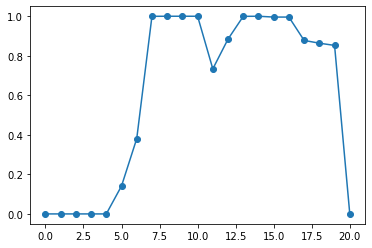

In [ ]:
MD_path = "/localhome/shuchen/projects/ALG8/post_transfer/simulations/stripped/"
prm = f'{MD_path}/ALG8_D36_post_transfer_stripped.prmtop'
nc = f'{MD_path}/ALG8_D36_post_transfer_run4.nc'
traj = pt.load(nc, top=prm)
dssp = pt.dssp(traj, simplified=True, mask=f":20-40")
alpha_perres = np.mean(dssp[1] == 'H', axis=0)
plt.plot(alpha_perres, marker='o')

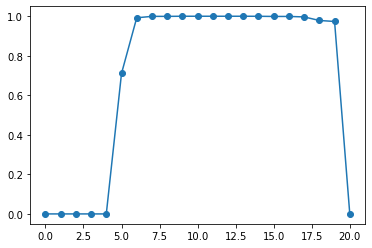

In [ ]:
MD_path = "/localhome/shuchen/projects/ALG8/post_transfer/simulations/stripped/"
prm = f'{MD_path}/ALG8_D36_H40d_post_transfer_stripped.prmtop'
nc = f'{MD_path}/ALG8_D36_H40d_post_transfer_run3.nc'
traj = pt.load(nc, top=prm)
dssp = pt.dssp(traj, simplified=True, mask=f":20-40")
alpha_perres = np.mean(dssp[1] == 'H', axis=0)
plt.plot(alpha_perres, marker='o')

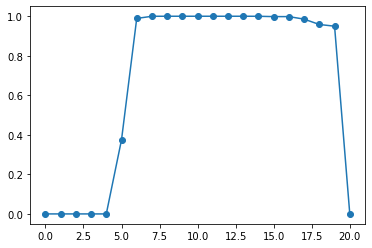

In [ ]:
MD_path = "/localhome/shuchen/projects/ALG8/post_transfer/simulations/stripped/"
prm = f'{MD_path}/ALG8_N36_post_transfer_stripped.prmtop'
nc = f'{MD_path}/ALG8_N36_post_transfer_run1.nc'
traj = pt.load(nc, top=prm)
dssp = pt.dssp(traj, simplified=True, mask=f":20-40")
alpha_perres = np.mean(dssp[1] == 'H', axis=0)
plt.plot(alpha_perres, marker='o')

In [ ]:
alpha_perres.shape

(21,)